# Explorez deux algorithmes de classification

## Étape 1 – Effectuez une analyse exploratoire du problème et des données


**Résultat attendu**

Du code Python (ou un notebook) qui charge le dataset et le prépare pour la suite de l'exploration.

**Recommandations**

- Pour prendre en main le dataset, utiliser pandas avec `df.head()` et `df.info()` pour comprendre sa structure.
- Vérifier la présence de doublons ou de valeurs invalides.
- Générer un histogramme de la distribution des étiquettes dans le dataset.
- Utiliser scikit-learn pour définir les datasets de train/test et les métriques d'évaluation.
- Inclure une métrique de temps de réponse afin d'évaluer l'expérience produit proposée par les algorithmes.

### CSV -> PANDAS : Découverte initiale

In [1]:
import pandas as pd

df = pd.read_csv("data/dataset.csv", low_memory=False)
df.info()
df.dropna().head(5)


<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1282355 non-null  str  
 1   Tag                           1282355 non-null  str  
 2   Consumer Claim                383564 non-null   str  
 3   Company public response       449082 non-null   str  
 4   Company                       1282355 non-null  str  
 5   State                         1262955 non-null  str  
 6   ZIP code                      1167057 non-null  str  
 7   Tags                          175643 non-null   str  
 8   Consumer consent provided?    690654 non-null   str  
 9   Submitted via                 1282355 non-null  str  
 10  Date sent to company          1282355 non-null  str  
 11  Company response to consumer  1282348 non-null  str  
 12  Timely response?              1282355 non-null  str  
 13  Consumer

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
513866,04/21/2017,Consumer Loan,I went to a dealership to purchase a vehicle. ...,Company believes it acted appropriately as aut...,UNITED SERVICES AUTOMOBILE ASSOCIATION,TX,782XX,Servicemember,Consent provided,Web,04/21/2017,Closed with explanation,Yes,No,2446242
513883,04/21/2017,Credit reporting,I have submitted several attempts to get this ...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,GA,30061,Servicemember,Consent provided,Web,04/21/2017,Closed with explanation,Yes,No,2445138
513922,04/21/2017,Credit reporting,A tax lien was issued in XXXX while I was ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,320XX,Servicemember,Consent provided,Web,04/21/2017,Closed with non-monetary relief,Yes,No,2447615
513936,04/21/2017,Payday loan,Been getting harrassing calls fr om Monterey F...,Company believes it acted appropriately as aut...,Monterey Financial Services LLC,TX,760XX,Servicemember,Consent provided,Web,04/21/2017,Closed with explanation,Yes,No,2446777
513945,04/21/2017,Bank account or service,This is a complaint agains t Wells Fargo Mo rt...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,NC,275XX,Older American,Consent provided,Web,04/21/2017,Closed with explanation,Yes,No,2446913


### Détection de doublons / valeurs invalides

In [2]:
# --- Duplicate check (single pass) ---
dup_mask = df.duplicated()
duplicate_count = int(dup_mask.sum())
has_duplicates = duplicate_count > 0

print(f"Has duplicates: {has_duplicates}")
print(f"Duplicate count: {duplicate_count}")
if has_duplicates:
    print("Duplicate preview (first 5 rows):")
    display(df.loc[dup_mask].head(5))

# --- Cardinality / unique values ---
columns_unique_value = df.nunique(dropna=False)
print("Unique values per column:")
display(columns_unique_value)

if "Tags" in df.columns:
    tags_unique_value = df["Tags"].dropna().unique()
    print(f"Tags unique count: {len(tags_unique_value)}")
    print("Tags preview:", tags_unique_value[:20])
else:
    print("Column 'Tags' not found in dataset.")

if "Tag" in df.columns:
    tags_unique_value = df["Tag"].dropna().unique()
    print(f"Tag unique count: {len(tags_unique_value)}")
    print("Tag preview:", tags_unique_value[:20])
else:
    print("Column 'Tag' not found in dataset.")

# --- Missing values (isna == isnull, keep one only) ---
columns_nan_count = df.isna().sum()
print("Missing values per column:")
display(columns_nan_count)

# Trace: previously checked that 'Complaint ID' has no negative values.

Has duplicates: False
Duplicate count: 0
Unique values per column:


Date received                      2717
Tag                                  18
Consumer Claim                   366946
Company public response              11
Company                            5275
State                                64
ZIP code                          22592
Tags                                  4
Consumer consent provided?            5
Submitted via                         6
Date sent to company               2666
Company response to consumer          9
Timely response?                      2
Consumer disputed?                    3
Complaint ID                    1282355
dtype: int64

Tags unique count: 3
Tags preview: <StringArray>
['Older American', 'Servicemember', 'Older American, Servicemember']
Length: 3, dtype: str
Tag unique count: 18
Tag preview: <StringArray>
[                                                 'Checking or savings account',
                                                              'Debt collection',
 'Credit reporting, credit repair services, or other personal consumer reports',
                                                                     'Mortgage',
                                                                 'Student loan',
                                                        'Vehicle loan or lease',
                                                  'Credit card or prepaid card',
                                    'Payday loan, title loan, or personal loan',
                           'Money transfer, virtual currency, or money service',
                                                             'Credit reporting',
  

Date received                         0
Tag                                   0
Consumer Claim                   898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Consumer disputed?               513854
Complaint ID                          0
dtype: int64

### Historigramme de la distribution des étiquettes dans le temps

<Axes: xlabel='Count', ylabel='Tag'>

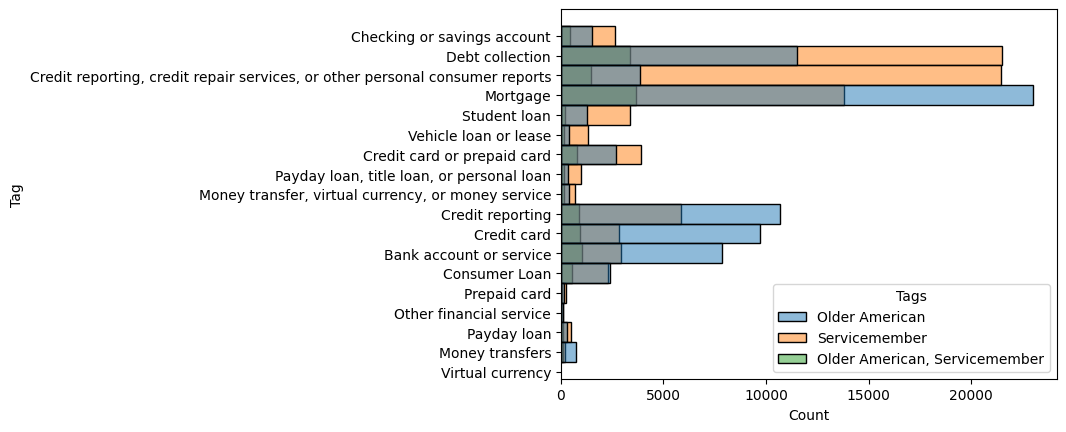

In [3]:
import seaborn as sns

sns.histplot(data=df, y="Tag",hue="Tags")


### Consolidation des étiquettes : de 18 à 11 catégories

Le dataset brut contient **18 valeurs distinctes** dans la colonne `Tag`. Plusieurs de ces étiquettes désignent le même produit financier sous des formulations différentes (renommages historiques du CFPB). D'autres catégories sont trop rares pour permettre un apprentissage fiable.

**Regroupements par redondance sémantique (synonymes / variantes historiques) :**

| Étiquettes originales | → Label consolidé |
|---|---|
| *Credit reporting, credit repair services, or other personal consumer reports* / *Credit reporting* | **Credit reporting** |
| *Credit card or prepaid card* / *Credit card* / *Prepaid card* | **Credit card** |
| *Bank account or service* / *Checking or savings account* | **Bank account** |
| *Payday loan, title loan, or personal loan* / *Payday loan* | **Payday loan** |
| *Money transfer, virtual currency, or money service* / *Money transfers* | **Money transfer** |

**Absorption des catégories rares :**

| Étiquette originale | Effectif | → Label consolidé | Raison |
|---|---|---|---|
| *Virtual currency* | 18 | **Other financial service** | Trop peu d'exemples pour un apprentissage fiable |

**Catégories conservées telles quelles** (effectifs suffisants, pas d'ambiguïté) :
Mortgage, Debt collection, Student loan, Consumer Loan, Vehicle loan or lease, Other financial service.

**Résultat final : 11 catégories consolidées** utilisées pour l'ensemble des expériences (LLM, ML classique, ModernBERT).

## Étape 2 - Évaluez l’approche LLM

### Initialisation Weave — observabilité LLM

In [ ]:
import os
from pathlib import Path
import weave

# ── Config Weave / W&B ───────────────────────────────────────────────────────
# Weave (Weights & Biases) est utilisé pour le suivi des traces LLM.
# Il est OPTIONNEL : si WANDB_API_KEY n'est pas défini dans .env,
# le notebook fonctionne normalement sans traçabilité Weave.
#
# ALTERNATIVE SANS COMPTE W&B :
#   - Désactivez Weave en mettant ENABLE_WANDB = False ci-dessous
#   - Les métriques sont calculées et affichées localement dans le notebook
#   - Pour un suivi d'expériences alternatif : MLflow (open-source, self-hosted)
ENABLE_WANDB = True
WANDB_PROJECT = "p12-ticket-classification"
ENV_PATH = Path(".env")

def load_env_file(path: Path) -> None:
    if not path.exists():
        return
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip())

load_env_file(ENV_PATH)

WANDB_READY = False
if ENABLE_WANDB:
    api_key = os.getenv("WANDB_API_KEY", "").strip()
    if api_key:
        import wandb

        logged_in = wandb.login(key=api_key, relogin=True, timeout=30)
        os.environ.setdefault("WANDB_PROJECT", WANDB_PROJECT)
        WANDB_READY = bool(logged_in)
        print(f"wandb login: {'OK' if WANDB_READY else 'failed'}")
    else:
        print("wandb disabled: WANDB_API_KEY not found in environment")
else:
    print("wandb disabled by config")

# Initialise Weave — traces LLM accessibles sur https://wandb.ai
if WANDB_READY:
    weave.init(WANDB_PROJECT)
    print(f"weave init OK — project: {WANDB_PROJECT}")
else:
    print("weave skipped (wandb not ready)")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/will/.netrc
wandb: Currently logged in as: william-derue to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb login: OK


weave: Logged in as Weights & Biases user: william-derue.
weave: View Weave data at https://wandb.ai/william-derue/p12-ticket-classification/weave


weave init OK — project: p12-ticket-classification


### Pipeline LLM (run de test) — sous-ensemble stratifié de 50 tickets

#### Configuration du moteur d'inférence

In [ ]:
import re
import requests
import pandas as pd

# ── Configuration endpoint LLM ────────────────────────────────────────────────
# Ce notebook utilise un endpoint OpenAI-compatible (vLLM local sur DGX Spark).
#
# ALTERNATIVE SANS SERVEUR LOCAL :
# Si vous n'avez pas de GPU local, utilisez l'API Mistral AI :
#   VLLM_BASE_URL = "https://api.mistral.ai"  (défaut si variable non définie)
#   Créez un fichier .env avec : MISTRAL_API_KEY=votre_clé
#   Le modèle recommandé est "mistral-medium-latest" (~$0.40/M tokens input)
#   Voir la section coût & scalabilité du notebook pour l'estimation des coûts.
# Tout provider OpenAI-compatible fonctionne (OpenAI, Together, Groq, etc.).
VLLM_BASE_URL = os.getenv("VLLM_BASE_URL", "https://api.mistral.ai")
OPENAI_BASE_URL = f"{VLLM_BASE_URL}/v1"

endpoint_probe = {
    "base_url": VLLM_BASE_URL,
    "openai_base_url": OPENAI_BASE_URL,
    "health_ok": None,
    "served_model": None,
    "model_count": 0,
    "models": [],
    "version": None,
    "metrics_excerpt": None,
    "max_num_seqs": None,
    "max_num_seqs_source": None,
}

# 1) Health check
try:
    health_resp = requests.get(f"{VLLM_BASE_URL}/health", timeout=10)
    endpoint_probe["health_ok"] = health_resp.status_code == 200
except Exception:
    endpoint_probe["health_ok"] = False

# 2) OpenAI-compatible models endpoint
try:
    models_resp = requests.get(f"{OPENAI_BASE_URL}/models", timeout=15)
    models_resp.raise_for_status()
    model_items = models_resp.json().get("data", [])
    model_ids = [m.get("id", "") for m in model_items if m.get("id")]
    endpoint_probe["models"] = model_ids
    endpoint_probe["model_count"] = len(model_ids)
    endpoint_probe["served_model"] = model_ids[0] if model_ids else None
except Exception as exc:
    endpoint_probe["models_error"] = str(exc)

# 3) Optional vLLM info endpoints
try:
    version_resp = requests.get(f"{VLLM_BASE_URL}/version", timeout=10)
    if version_resp.ok:
        endpoint_probe["version"] = version_resp.text.strip()
except Exception:
    pass

try:
    metrics_resp = requests.get(f"{VLLM_BASE_URL}/metrics", timeout=10)
    if metrics_resp.ok:
        metrics_text = metrics_resp.text
        endpoint_probe["metrics_excerpt"] = "\n".join(metrics_text.splitlines()[:8])

        # Try to extract max_num_seqs if exposed by this vLLM build.
        patterns = [
            r"max_num_seqs\s*[=:]\s*(\d+)",
            r"vllm:.*max.*seq.*\s(\d+(?:\.\d+)?)$",
            r"scheduler_config_max_num_seqs\s*[=:]\s*(\d+)",
        ]
        found = None
        for pattern in patterns:
            match = re.search(pattern, metrics_text, flags=re.IGNORECASE | re.MULTILINE)
            if match:
                found = int(float(match.group(1)))
                endpoint_probe["max_num_seqs"] = found
                endpoint_probe["max_num_seqs_source"] = f"metrics:{pattern}"
                break
except Exception:
    pass

print("=== Endpoint Probe ===")
print(f"Health OK: {endpoint_probe['health_ok']}")
print(f"Model served: {endpoint_probe['served_model']}")
print(f"Model count: {endpoint_probe['model_count']}")
if endpoint_probe.get("version"):
    print(f"Version: {endpoint_probe['version']}")

if endpoint_probe.get("max_num_seqs") is not None:
    print(f"max_num_seqs détecté: {endpoint_probe['max_num_seqs']}")
else:
    print("max_num_seqs non exposé par cet endpoint (fallback auto requis)")
    endpoint_probe["max_num_seqs"] = 32

display(pd.DataFrame([{
    "base_url": endpoint_probe["base_url"],
    "openai_base_url": endpoint_probe["openai_base_url"],
    "health_ok": endpoint_probe["health_ok"],
    "served_model": endpoint_probe["served_model"],
    "model_count": endpoint_probe["model_count"],
    "max_num_seqs": endpoint_probe["max_num_seqs"],
    "max_num_seqs_source": endpoint_probe["max_num_seqs_source"],
}]))

if endpoint_probe.get("metrics_excerpt"):
    print("\nMetrics excerpt:")
    print(endpoint_probe["metrics_excerpt"])

In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Any
import re
import time
import weave
from openai import OpenAI
from sklearn.model_selection import train_test_split

# ── Config ────────────────────────────────────────────────────────────────────
LLM_TARGET_COL = "Tag"
LLM_TEXT_COL = "Consumer Claim"
LLM_SAMPLE_SIZE = 1000
LLM_RANDOM_STATE = 42
LLM_MAX_RETRIES = 2
ENABLE_PROMPT_EVAL = True
PROMPT_EVAL_SAMPLE_SIZE = 100

# ── Connexion au LLM ─────────────────────────────────────────────────────────
# Le client OpenAI est universel : il fonctionne avec tout endpoint compatible
# (vLLM local, Mistral AI, OpenAI, Together, Groq, etc.).
# Adaptez VLLM_BASE_URL et le modèle selon votre provider.
#
# Exemples de configuration :
#   Mistral AI  : VLLM_BASE_URL=https://api.mistral.ai  / model=mistral-medium-latest
#   OpenAI      : VLLM_BASE_URL=https://api.openai.com   / model=gpt-4o-mini
#   vLLM local  : VLLM_BASE_URL=http://localhost:8000     / model=<auto-détecté>
LLM_BASE_URL = endpoint_probe["openai_base_url"]
LLM_MODEL_NAME = endpoint_probe["served_model"] or "mistral-medium-latest"

if not endpoint_probe.get("health_ok", False):
    raise RuntimeError("Endpoint LLM indisponible. Vérifiez VLLM_BASE_URL dans .env ou /health.")
if not LLM_MODEL_NAME:
    raise RuntimeError("Aucun modèle exposé sur /v1/models.")

# ── Label consolidation (15+ raw tags → 11 clean labels) ─────────────────────
LABEL_CONSOLIDATION_MAP = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",
    "Credit card": "Credit card",
    "Credit card or prepaid card": "Credit card",
    "Prepaid card": "Credit card",
    "Bank account or service": "Bank account",
    "Checking or savings account": "Bank account",
    "Payday loan": "Payday loan",
    "Payday loan, title loan, or personal loan": "Payday loan",
    "Money transfer, virtual currency, or money service": "Money transfer",
    "Money transfers": "Money transfer",
    "Mortgage": "Mortgage",
    "Debt collection": "Debt collection",
    "Student loan": "Student loan",
    "Consumer Loan": "Consumer Loan",
    "Vehicle loan or lease": "Vehicle loan or lease",
    "Other financial service": "Other financial service",
    "Virtual currency": "Other financial service",
}

# ── Prepare eval set with consolidated labels ────────────────────────────────
df_llm = df.dropna(subset=[LLM_TARGET_COL, LLM_TEXT_COL]).copy()
df_llm["label_consolidated"] = df_llm[LLM_TARGET_COL].map(LABEL_CONSOLIDATION_MAP)
df_llm = df_llm.dropna(subset=["label_consolidated"]).reset_index(drop=True)

llm_train_df, llm_eval_df = train_test_split(
    df_llm,
    test_size=LLM_SAMPLE_SIZE,
    stratify=df_llm["label_consolidated"],
    random_state=LLM_RANDOM_STATE,
)
llm_eval_df = llm_eval_df.reset_index(drop=True)

# The 11 consolidated labels are what the LLM must choose from.
allowed_labels = sorted(df_llm["label_consolidated"].unique().tolist())
allowed_lookup = {label.strip().lower(): label for label in allowed_labels}

print(f"Consolidated labels ({len(allowed_labels)}): {allowed_labels}")
print(f"Eval distribution:\n{llm_eval_df['label_consolidated'].value_counts().to_string()}")

# ── Category descriptions (helps the model disambiguate similar labels) ──────
LABEL_DESCRIPTIONS = {
    "Bank account": "Checking/savings account issues: fees, access, opening/closing, fraud on account",
    "Consumer Loan": "Personal loans, installment loans, and general consumer lending issues",
    "Credit card": "Credit card or prepaid card: billing disputes, fees, rewards, fraud, APR issues",
    "Credit reporting": "Credit reports, credit scores, disputes with reporting agencies (Equifax, Experian, TransUnion)",
    "Debt collection": "Harassment by collectors, disputed debts, communication tactics, validation of debt",
    "Money transfer": "Wire transfers, money orders, remittances, virtual currency, and money service issues",
    "Mortgage": "Home loans: applications, closing, payments, escrow, foreclosure, refinancing",
    "Other financial service": "Financial services not covered by other categories (e.g. credit repair, foreign exchange)",
    "Payday loan": "Payday loans, title loans, personal loans: high-interest short-term lending issues",
    "Student loan": "Federal and private student loan issues: repayment, deferment, forgiveness, servicer problems",
    "Vehicle loan or lease": "Auto loans and leases: payments, repossession, GAP insurance, dealer financing",
}

# ── Few-shot examples (2 per class, from train split to avoid data leakage) ──
LLM_FEW_SHOT_N = 2
_fewshot_rng = LLM_RANDOM_STATE

few_shot_examples: list[tuple[str, str]] = []
for label in allowed_labels:
    pool = llm_train_df[llm_train_df["label_consolidated"] == label]
    samples = pool.sample(n=min(LLM_FEW_SHOT_N, len(pool)), random_state=_fewshot_rng)
    for _, row in samples.iterrows():
        text_snippet = str(row[LLM_TEXT_COL])[:300].strip()
        few_shot_examples.append((text_snippet, label))

print(f"\nFew-shot examples: {len(few_shot_examples)} ({LLM_FEW_SHOT_N} per class)")
print(f"Example: {few_shot_examples[0][1]} -> {few_shot_examples[0][0][:80]}...")

# ── Fuzzy matching helpers ───────────────────────────────────────────────────
def simplify_text(s: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", s.lower())).strip()

allowed_simple_lookup: dict[str, str] = {}
for label in allowed_labels:
    simple = simplify_text(label)
    if simple:
        allowed_simple_lookup[simple] = label

# ── Workers (concurrency) ─────────────────────────────────────────────────────
LLM_MAX_WORKERS = 2
workers_source = "benchmark:pp2048_optimal_c2"

client = OpenAI(
    api_key="unused",
    base_url=LLM_BASE_URL,
    timeout=45.0,
)

# ── System Prompts — 5 variantes pour comparaison ────────────────────────────
SYSTEM_PROMPTS: dict[str, str] = {
    "v1_baseline": (
        "You are an expert classifier for consumer financial complaint tickets. "
        "Your task is to assign each ticket to exactly ONE category from the provided list. "
        "Read the ticket carefully and reply with ONLY the category label — no explanation, no punctuation, no extra text."
    ),
    "v2_minimal": (
        "Classify the following consumer complaint into one category. "
        "Reply with ONLY the category label."
    ),
    "v3_structured_json": (
        "You are a text classifier for consumer financial complaints. "
        "Respond with ONLY a valid JSON object containing one key 'label' with the category name as value. "
        "No explanation, no extra text."
    ),
    "v4_cot_brief": (
        "You are an expert classifier for consumer financial complaints. "
        "First, identify the main financial product or service mentioned in the complaint. "
        "Then classify the complaint into exactly one category from the provided list. "
        "Reply with ONLY the category label on the last line."
    ),
    "v5_expert_persona": (
        "You are a senior financial compliance analyst at the CFPB (Consumer Financial Protection Bureau) "
        "with 15 years of experience categorizing consumer complaints. "
        "You are precise, consistent, and always assign complaints to the most specific applicable category. "
        "Your task: read the consumer complaint and assign it to exactly ONE category from the provided list. "
        "Reply with ONLY the category label — no commentary, no punctuation, no extra text."
    ),
}
system_prompt = SYSTEM_PROMPTS["v1_baseline"]

# ── Build the few-shot block once (shared across all calls) ──────────────────
_fewshot_block_lines = []
for ex_text, ex_label in few_shot_examples:
    _fewshot_block_lines.append(f"Ticket: {ex_text}\nLabel: {ex_label}")
_fewshot_block = "\n\n".join(_fewshot_block_lines)

# ── Build the label+description block once ───────────────────────────────────
_labels_block = "\n".join(
    f"- {label}: {LABEL_DESCRIPTIONS.get(label, '')}" for label in allowed_labels
)

def build_user_message(text: str, variant: str = "v1_baseline") -> str:
    """Build the user message adapted to each prompt variant."""
    ticket_section = f"## Ticket to classify\n{text[:3000]}\n\nLabel:"
    if variant in ("v1_baseline", "v5_expert_persona"):
        return f"## Categories\n{_labels_block}\n\n## Examples\n{_fewshot_block}\n\n{ticket_section}"
    elif variant == "v2_minimal":
        _min_labels = "\n".join(f"- {lbl}" for lbl in allowed_labels)
        return f"## Categories\n{_min_labels}\n\n{ticket_section}"
    elif variant in ("v3_structured_json", "v4_cot_brief"):
        return f"## Categories\n{_labels_block}\n\n{ticket_section}"
    return f"## Categories\n{_labels_block}\n\n## Examples\n{_fewshot_block}\n\n{ticket_section}"

def normalize_label(raw: str) -> str | None:
    s = raw.strip().strip('"').strip("'")
    # JSON extraction (v3_structured_json variant)
    if "{" in s:
        try:
            import json as _json
            _json_match = re.search(r'\{[^}]+\}', s)
            if _json_match:
                parsed = _json.loads(_json_match.group())
                if isinstance(parsed, dict) and "label" in parsed:
                    s = str(parsed["label"]).strip()
        except (ValueError, KeyError):
            pass
    s = re.sub(r"^label\s*:\s*", "", s, flags=re.IGNORECASE)
    s = s.strip()
    if not s:
        return None

    # Exact match (case-insensitive)
    key = s.lower()
    if key in allowed_lookup:
        return allowed_lookup[key]

    # First line only
    first_line = s.splitlines()[0].strip().strip('"').strip("'").lower()
    if first_line in allowed_lookup:
        return allowed_lookup[first_line]

    # Simplified match
    simple = simplify_text(first_line)
    if simple in allowed_simple_lookup:
        return allowed_simple_lookup[simple]

    # Prefix match
    for label in allowed_labels:
        low = label.lower()
        if first_line and (low.startswith(first_line) or first_line.startswith(low)):
            return label

    return None

@weave.op()
def call_llm(
    text: str,
    use_guided_choice: bool,
    system_prompt_override: str | None = None,
    variant: str = "v1_baseline",
) -> tuple[str | None, float, str | None]:
    t0 = time.perf_counter()
    extra_body: dict[str, Any] = {
        "chat_template_kwargs": {"enable_thinking": False},
    }
    if use_guided_choice:
        extra_body["guided_choice"] = allowed_labels
    _sys = system_prompt_override or system_prompt
    _user_msg = build_user_message(text, variant)

    try:
        with weave.attributes({
            "model_name": LLM_MODEL_NAME,
            "provider": "vllm",
            "endpoint": LLM_BASE_URL,
            "thinking_mode": False,
            "guided_choice": use_guided_choice,
            "prompt_variant": variant,
        }):
            response = client.chat.completions.create(
                model=LLM_MODEL_NAME,
                temperature=0.7,
                top_p=0.8,
                max_tokens=30,
                messages=[
                    {"role": "system", "content": _sys},
                    {"role": "user", "content": _user_msg},
                ],
                extra_body=extra_body,
            )
        latency_s = time.perf_counter() - t0
        raw = response.choices[0].message.content or ""
        pred = normalize_label(raw)
        if pred is not None:
            return pred, latency_s, None
        return None, latency_s, f"Label hors liste: {raw[:180]}"
    except Exception as exc:
        latency_s = time.perf_counter() - t0
        return None, latency_s, str(exc)

# ── Weave Model — versioned classifier ────────────────────────────────────────
class TicketClassifier(weave.Model):
    model_name: str
    endpoint: str
    system_prompt_name: str = "v1_baseline"
    use_guided_choice: bool = True
    temperature: float = 0.7
    top_p: float = 0.8
    max_tokens: int = 30
    thinking_mode: bool = False
    max_retries: int = 2
    few_shot_count: int = 2

    @weave.op()
    def predict(self, text: str) -> dict:
        """Classify one ticket with retry logic (guided_choice → free-form)."""
        sys_prompt = SYSTEM_PROMPTS.get(self.system_prompt_name, system_prompt)
        last_err: str | None = None
        last_latency_s = 0.0
        for _ in range(self.max_retries + 1):
            if self.use_guided_choice:
                pred, latency_s, err = call_llm(text, use_guided_choice=True, system_prompt_override=sys_prompt, variant=self.system_prompt_name)
                if pred is not None:
                    return {"label": pred, "latency_s": latency_s, "error": None}
                last_err = err
                last_latency_s = latency_s
            pred, latency_s, err = call_llm(text, use_guided_choice=False, system_prompt_override=sys_prompt, variant=self.system_prompt_name)
            if pred is not None:
                return {"label": pred, "latency_s": latency_s, "error": None}
            last_err = err
            last_latency_s = latency_s
        return {"label": None, "latency_s": last_latency_s, "error": last_err}

classifier = TicketClassifier(
    model_name=LLM_MODEL_NAME,
    endpoint=LLM_BASE_URL,
    system_prompt_name="v1_baseline",
    temperature=0.7,
    top_p=0.8,
    max_tokens=30,
    thinking_mode=False,
    max_retries=LLM_MAX_RETRIES,
    few_shot_count=LLM_FEW_SHOT_N,
)

# ── Publish eval dataset to Weave (links predictions to dataset rows in UI) ──
eval_dataset = weave.Dataset(
    name=f"ticket-eval-{LLM_SAMPLE_SIZE}",
    rows=[
        {
            "text": str(llm_eval_df.loc[i, LLM_TEXT_COL])[:500],
            "expected": str(llm_eval_df.loc[i, "label_consolidated"]),
        }
        for i in range(len(llm_eval_df))
    ],
)
try:

    weave.publish(eval_dataset)    f"\nWeave Model: {classifier.__class__.__name__} v{classifier.model_name}")

    print(f"Weave Dataset publié: ticket-eval-{LLM_SAMPLE_SIZE} ({len(llm_eval_df)} rows)")    f"labels={len(allowed_labels)}, workers={LLM_MAX_WORKERS} ({workers_source})"

except Exception as _weave_err:    f"\nConfig LLM prête: model={LLM_MODEL_NAME}, sample={len(llm_eval_df)}, "

    print(f"⚠ Weave publish skipped ({_weave_err.__class__.__name__}). Lancez la cellule 12 d'abord.")print(


Consolidated labels (11): ['Bank account', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfer', 'Mortgage', 'Other financial service', 'Payday loan', 'Student loan', 'Vehicle loan or lease']
Eval distribution:
label_consolidated
Credit reporting           323
Debt collection            226
Mortgage                   138
Credit card                109
Bank account                72
Student loan                57
Consumer Loan               25
Money transfer              18
Payday loan                 16
Vehicle loan or lease       15
Other financial service      1

Few-shot examples: 22 (2 per class)
Example: Bank account -> I was the victim of a scam/fraud on my bank account XX/XX/XXXX. I notified the b...


weave: 📦 Published to https://wandb.ai/william-derue/p12-ticket-classification/weave/objects/ticket-eval-1000/versions/f8NKYAVs3hUqpNF0w2dJgsNVtdDYkzPYQGlxr09mbuo


Weave Dataset publié: ticket-eval-1000 (1000 rows)

Config LLM prête: model=Intel/Qwen3.5-122B-A10B-int4-AutoRound, sample=1000, labels=11, workers=2 (benchmark:pp2048_optimal_c2)
Weave Model: TicketClassifier vIntel/Qwen3.5-122B-A10B-int4-AutoRound


#### Execution de l'inférence

In [7]:
from tqdm.auto import tqdm

def infer_row(i: int) -> tuple[int, dict]:
    text = str(llm_eval_df.loc[i, LLM_TEXT_COL])
    result = classifier.predict(text)
    return i, result

results_map: dict[int, dict] = {}
t_start = time.perf_counter()

with ThreadPoolExecutor(max_workers=LLM_MAX_WORKERS) as executor:
    futures = [executor.submit(infer_row, i) for i in range(len(llm_eval_df))]
    with tqdm(total=len(llm_eval_df), desc="LLM inference", unit="ticket") as pbar:
        for fut in as_completed(futures):
            i, result = fut.result()
            results_map[i] = result
            pbar.update(1)

t_total = time.perf_counter() - t_start
results_ordered = [results_map[i] for i in range(len(llm_eval_df))]

llm_eval_df["llm_pred"] = [r["label"] for r in results_ordered]
llm_eval_df["latency_s"] = [r["latency_s"] for r in results_ordered]
llm_eval_df["llm_error"] = [r["error"] for r in results_ordered]

valid_mask = llm_eval_df["llm_pred"].notna()
valid_count = int(valid_mask.sum())
failed_count = len(llm_eval_df) - valid_count

print("=== Inference Summary ===")
print(f"Tickets soumis: {len(llm_eval_df)}")
print(f"Labels valides: {valid_count}/{len(llm_eval_df)} ({valid_count/len(llm_eval_df)*100:.1f}%)")
print(f"Échecs: {failed_count}")
print(f"Temps total: {t_total:.1f}s | Débit: {len(llm_eval_df)/t_total:.1f} req/s")
print(f"Latence: mean={llm_eval_df['latency_s'].mean()*1000:.0f}ms | P95={llm_eval_df['latency_s'].quantile(0.95)*1000:.0f}ms")

# ── Evaluation on valid predictions (against consolidated labels) ─────────────
if valid_count > 0:
    from sklearn.metrics import classification_report, f1_score, accuracy_score

    valid_df = llm_eval_df[valid_mask].copy()
    y_true = valid_df["label_consolidated"]
    y_pred = valid_df["llm_pred"]

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, labels=allowed_labels, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, labels=allowed_labels, average="weighted", zero_division=0)

    print(f"\n=== Evaluation LLM (sur {valid_count} prédictions valides) ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print()
    print(classification_report(y_true, y_pred, labels=allowed_labels, zero_division=0))

    # Error analysis
    errors_df = llm_eval_df[llm_eval_df["llm_error"].notna()]
    if len(errors_df) > 0:
        print(f"\n=== Erreurs ({len(errors_df)}) ===")
        print(errors_df["llm_error"].value_counts().head(10).to_string())
        print("\nExemples:")
        display(errors_df[[LLM_TEXT_COL, LLM_TARGET_COL, "label_consolidated", "llm_error"]].head(5))

LLM inference:   0%|          | 0/1000 [00:00<?, ?ticket/s]

weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-1f93-72c8-8d8c-5a2f389d3d2e
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-1f93-7ce9-9d17-8e3bbc1728af
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-27d4-7ae4-ad88-ba3544050250
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-27fa-74be-bb87-1080671ed6b9
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-305f-75db-844d-a77e7d8cb0d5
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-32dc-7eb7-93d0-9043f2fd2dc1
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-3947-7213-a453-94b15d8741bd
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-3b64-73fa-bc24-d017e6e2d85b
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62c9-4235-70a4-afb4-0af5828eeaf2
weave: 🍩 h

=== Inference Summary ===
Tickets soumis: 1000
Labels valides: 1000/1000 (100.0%)
Échecs: 0
Temps total: 1057.6s | Débit: 0.9 req/s
Latence: mean=2114ms | P95=2638ms

=== Evaluation LLM (sur 1000 prédictions valides) ===
Accuracy: 0.8200
F1 macro: 0.6617
F1 weighted: 0.8224

                         precision    recall  f1-score   support

           Bank account       0.87      0.81      0.83        72
          Consumer Loan       0.30      0.12      0.17        25
            Credit card       0.80      0.79      0.80       109
       Credit reporting       0.82      0.87      0.84       323
        Debt collection       0.90      0.73      0.81       226
         Money transfer       0.88      0.83      0.86        18
               Mortgage       0.94      0.99      0.96       138
Other financial service       0.00      0.00      0.00         1
            Payday loan       0.58      0.69      0.63        16
           Student loan       0.88      0.89      0.89        57
  Vehicl

#### Monitoring session vLLM — métriques runtime après inférence

=== Session Inference Performance ===


,kpi,value
0,latency_source,client_per_ticket
1,tickets_total,1000
2,temps_total_s,1057.58
3,throughput_tickets_s,0.946
4,throughput_tickets_min,56.733
5,latency_mean_ms,2114.31
6,latency_median_ms,2098.677
7,latency_p95_ms,2638.415
8,latency_p99_ms,2992.517
9,dataset_tickets_total,383564


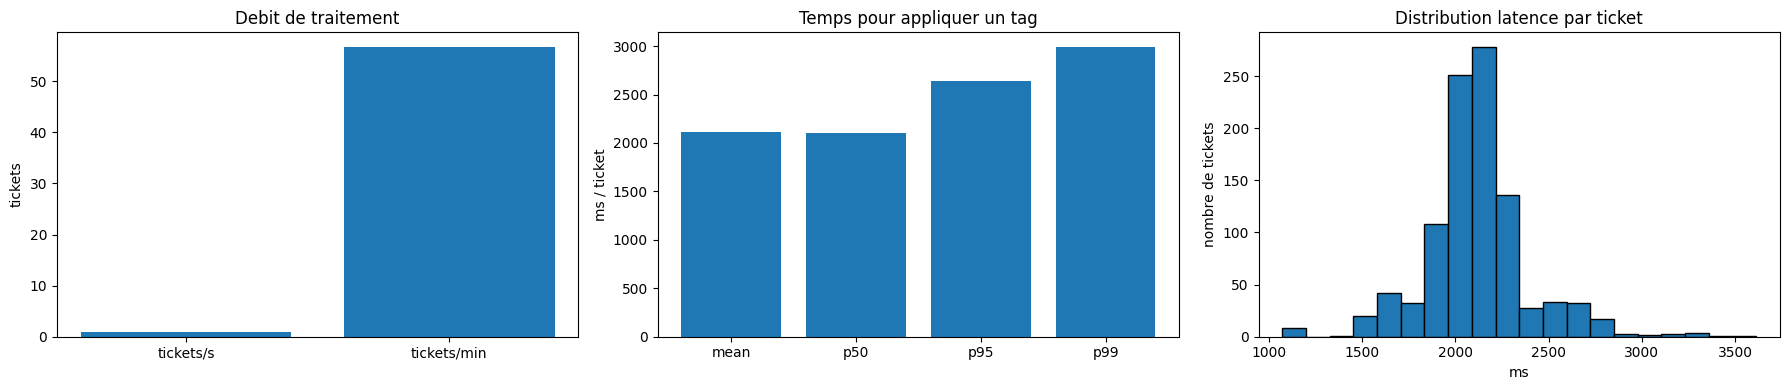

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Dashboard de performance de la session d'inference (centre produit)
n_tickets = len(llm_eval_df)
if n_tickets == 0:
    raise ValueError("Aucun ticket dans llm_eval_df. Executer la cellule de config/inference avant.")

if "latency_s" in llm_eval_df.columns:
    lat_ms = llm_eval_df["latency_s"].astype(float) * 1000.0
    latency_source = "client_per_ticket"
else:
    # Fallback si la cellule d'inference n'a pas encore ete executee
    if "t_total" not in globals() or float(t_total) <= 0:
        raise ValueError("Aucune latence disponible. Executer d'abord la cellule d'inference.")
    approx_ms = (float(t_total) / n_tickets) * 1000.0
    lat_ms = pd.Series([approx_ms] * n_tickets)
    latency_source = "fallback_avg_from_t_total"
    print("latency_s absente: fallback utilise (moyenne t_total/n_tickets).")

if "t_total" in globals() and float(t_total) > 0:
    total_s = float(t_total)
else:
    total_s = float(lat_ms.sum() / 1000.0)

# KPI principaux
mean_ms = float(lat_ms.mean())
median_ms = float(lat_ms.median())
p95_ms = float(lat_ms.quantile(0.95))
p99_ms = float(lat_ms.quantile(0.99))

throughput_s = n_tickets / total_s
throughput_min = throughput_s * 60.0

# Projection du temps de traitement pour le dataset consolidé (11 labels)
if "df_llm" in globals() and isinstance(df_llm, pd.DataFrame) and len(df_llm) > 0:
    dataset_tickets = int(len(df_llm))
else:
    dataset_tickets = None

session_rows = [
    {"kpi": "latency_source", "value": latency_source},
    {"kpi": "tickets_total", "value": n_tickets},
    {"kpi": "temps_total_s", "value": round(total_s, 3)},
    {"kpi": "throughput_tickets_s", "value": round(throughput_s, 3)},
    {"kpi": "throughput_tickets_min", "value": round(throughput_min, 3)},
    {"kpi": "latency_mean_ms", "value": round(mean_ms, 3)},
    {"kpi": "latency_median_ms", "value": round(median_ms, 3)},
    {"kpi": "latency_p95_ms", "value": round(p95_ms, 3)},
    {"kpi": "latency_p99_ms", "value": round(p99_ms, 3)},
]

if dataset_tickets is not None:
    projected_total_s = float(dataset_tickets / throughput_s)
    projected_total_h = projected_total_s / 3600.0

    h = int(projected_total_s // 3600)
    m = int((projected_total_s % 3600) // 60)
    s = int(projected_total_s % 60)
    projected_total_hms = f"{h:02d}:{m:02d}:{s:02d}"

    # Estimation prudente: si chaque ticket prenait la latence p95 observee
    projected_total_s_p95 = float((p95_ms / 1000.0) * dataset_tickets)
    h95 = int(projected_total_s_p95 // 3600)
    m95 = int((projected_total_s_p95 % 3600) // 60)
    s95 = int(projected_total_s_p95 % 60)
    projected_total_hms_p95 = f"{h95:02d}:{m95:02d}:{s95:02d}"

    session_rows.extend([
        {"kpi": "dataset_tickets_total", "value": dataset_tickets},
        {"kpi": "estimation_total_dataset_s", "value": round(projected_total_s, 1)},
        {"kpi": "estimation_total_dataset_h", "value": round(projected_total_h, 3)},
        {"kpi": "estimation_total_dataset_hms", "value": projected_total_hms},
        {"kpi": "estimation_prudente_p95_hms", "value": projected_total_hms_p95},
    ])

session_perf_df = pd.DataFrame(session_rows)

print("=== Session Inference Performance ===")
display(session_perf_df)

# Graphiques lisibles produit:
# 1) Debit (tickets/s et tickets/min)
# 2) Temps pour appliquer un tag (mean / p50 / p95 / p99)
# 3) Distribution des latences par ticket
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(["tickets/s", "tickets/min"], [throughput_s, throughput_min])
axes[0].set_title("Debit de traitement")
axes[0].set_ylabel("tickets")

lat_labels = ["mean", "p50", "p95", "p99"]
lat_values = [mean_ms, median_ms, p95_ms, p99_ms]
axes[1].bar(lat_labels, lat_values)
axes[1].set_title("Temps pour appliquer un tag")
axes[1].set_ylabel("ms / ticket")

axes[2].hist(lat_ms, bins=min(20, max(5, n_tickets // 2)), edgecolor="black")
axes[2].set_title("Distribution latence par ticket")
axes[2].set_xlabel("ms")
axes[2].set_ylabel("nombre de tickets")

plt.tight_layout()
plt.show()


#### Evaluation des résultat de l'inférence

In [9]:
# Cellule d'évaluation et métriques
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

n_submitted = int(len(llm_eval_df))
valid_mask = llm_eval_df["llm_pred"].notna()
n_labeled = int(valid_mask.sum())
n_failed = int(n_submitted - n_labeled)
coverage = (n_labeled / n_submitted) * 100.0 if n_submitted > 0 else 0.0

print("=== Evaluation LLM ===")
print(f"Tickets soumis: {n_submitted}")
print(f"Tickets labelisés (valides): {n_labeled}")
print(f"Tickets non labelisés / ratés: {n_failed}")
print(f"Couverture prédictions valides: {coverage:.1f}%")

if valid_mask.any():
    y_true = llm_eval_df.loc[valid_mask, "label_consolidated"]
    y_pred = llm_eval_df.loc[valid_mask, "llm_pred"]

    llm_acc = accuracy_score(y_true, y_pred)
    llm_f1_macro = f1_score(y_true, y_pred, labels=allowed_labels, average="macro", zero_division=0)
    llm_f1_weighted = f1_score(y_true, y_pred, labels=allowed_labels, average="weighted", zero_division=0)

    print(f"Accuracy (sur prédictions valides): {llm_acc:.4f}")
    print(f"F1 macro (sur prédictions valides): {llm_f1_macro:.4f}")
    print(f"F1 weighted (sur prédictions valides): {llm_f1_weighted:.4f}")

    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=allowed_labels,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    print(f"\nClassification report ({len(allowed_labels)} labels consolidés):")
    display(report.round(4))

    cm = confusion_matrix(y_true, y_pred, labels=allowed_labels)
    cm_df = pd.DataFrame(cm, index=allowed_labels, columns=allowed_labels)
    print(f"\nConfusion matrix ({len(allowed_labels)} labels consolidés):")
    display(cm_df)
else:
    print("Aucune prédiction valide — vérifier endpoint / modèle / format de sortie.")

# Diagnostic explicite des ratés de labelisation
error_mask = llm_eval_df["llm_error"].notna()
if error_mask.any():
    raw_failures = (
        llm_eval_df.loc[error_mask, "llm_error"]
        .astype(str)
        .str.replace(r"^Label hors liste:\s*", "", regex=True)
        .str.strip()
    )

    print("\nTop sorties brutes qui causent un échec (fréquence):")
    display(raw_failures.value_counts().head(10).rename_axis("sortie_brute").reset_index(name="count"))
else:
    print("\nAucune erreur de sortie brute détectée.")


=== Evaluation LLM ===
Tickets soumis: 1000
Tickets labelisés (valides): 1000
Tickets non labelisés / ratés: 0
Couverture prédictions valides: 100.0%
Accuracy (sur prédictions valides): 0.8200
F1 macro (sur prédictions valides): 0.6617
F1 weighted (sur prédictions valides): 0.8224

Classification report (11 labels consolidés):


,precision,recall,f1-score,support
Bank account,0.8657,0.8056,0.8345,72.00
Consumer Loan,0.3000,0.1200,0.1714,25.00
Credit card,0.8037,0.7890,0.7963,109.00
Credit reporting,0.8169,0.8700,0.8426,323.00
Debt collection,0.9022,0.7345,0.8098,226.00
Money transfer,0.8824,0.8333,0.8571,18.00
Mortgage,0.9379,0.9855,0.9611,138.00
Other financial service,0.0000,0.0000,0.0000,1.00
Payday loan,0.5789,0.6875,0.6286,16.00
Student loan,0.8793,0.8947,0.8870,57.00



Confusion matrix (11 labels consolidés):


,Bank account,Consumer Loan,Credit card,Credit reporting,Debt collection,Money transfer,Mortgage,Other financial service,Payday loan,Student loan,Vehicle loan or lease
Bank account,58,1,7,2,1,2,0,1,0,0,0
Consumer Loan,0,3,2,3,2,0,0,0,3,0,12
Credit card,5,0,86,13,1,0,0,4,0,0,0
Credit reporting,1,1,9,281,11,0,5,2,0,6,7
Debt collection,0,2,2,39,166,0,3,4,5,1,4
Money transfer,2,0,1,0,0,15,0,0,0,0,0
Mortgage,1,1,0,0,0,0,136,0,0,0,0
Other financial service,0,0,0,1,0,0,0,0,0,0,0
Payday loan,0,1,0,1,2,0,0,0,11,0,1
Student loan,0,0,0,3,1,0,1,0,0,51,1



Aucune erreur de sortie brute détectée.


#### Weave Evaluation — suivi structuré des prédictions LLM

Le `EvaluationLogger` enregistre chaque prédiction avec ses scores dans Weave, liée au `Dataset` et au `Model` versionnés.  
Résultats visibles dans **W&B Weave UI → onglet Evals**.

In [10]:
# ── Weave EvaluationLogger — log structuré des prédictions + scores ────────────
from weave import EvaluationLogger

eval_logger = EvaluationLogger(
    name="llm-ticket-classification",
    model=classifier,
    dataset=eval_dataset,
    scorers=["exact_match", "valid_prediction"],
)

for i in range(len(llm_eval_df)):
    expected = str(llm_eval_df.loc[i, "label_consolidated"])
    result = results_map[i]
    pred_label = result["label"]

    with eval_logger.log_prediction(
        inputs=eval_dataset.rows[i],
        output=result,
    ) as pred_log:
        pred_log.log_score("exact_match", pred_label == expected if pred_label else False)
        pred_log.log_score("valid_prediction", pred_label is not None)

# ── Summary avec métriques agrégées ──────────────────────────────────────────
eval_logger.log_summary({
    "accuracy": float(llm_acc),
    "f1_macro": float(llm_f1_macro),
    "f1_weighted": float(llm_f1_weighted),
    "coverage": n_labeled / n_submitted,
    "total_time_s": float(t_total),
    "throughput_req_s": float(n_submitted / t_total),
    "mean_latency_ms": float(llm_eval_df["latency_s"].mean() * 1000),
    "p95_latency_ms": float(llm_eval_df["latency_s"].quantile(0.95) * 1000),
})

print(f"✅ Weave Evaluation logged: {n_submitted} predictions, {n_labeled} valid")
print("→ Voir résultats dans W&B Weave UI → onglet 'Evals'")

weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-43db-7615-8e1b-ec8aec6a9b72


✅ Weave Evaluation logged: 1000 predictions, 1000 valid
→ Voir résultats dans W&B Weave UI → onglet 'Evals'


#### Comparaison des System Prompts (optionnel)

Test de 5 stratégies de prompting sur un échantillon réduit (`PROMPT_EVAL_SAMPLE_SIZE`), **sans `guided_choice`** pour évaluer le prompt pur.  
Chaque variante est loggée dans Weave → comparaison dans l'onglet **Evals**.

| Variante | Stratégie | Few-shot | Descriptions |
|---|---|---|---|
| `v1_baseline` | Rôle + tâche directe | ✅ | ✅ |
| `v2_minimal` | Zero-shot minimal | ❌ | ❌ |
| `v3_structured_json` | Sortie JSON structurée | ❌ | ✅ |
| `v4_cot_brief` | Chain-of-thought court | ❌ | ✅ |
| `v5_expert_persona` | Persona expert CFPB | ✅ | ✅ |

In [11]:
# ── Comparaison des System Prompts ────────────────────────────────────────────
if ENABLE_PROMPT_EVAL:
    import numpy as np
    import pandas as pd
    from sklearn.metrics import accuracy_score, f1_score
    from tqdm.auto import tqdm
    from weave import EvaluationLogger as _EvalLogger

    # Fallback si mean_ms n'existe pas (main inference non exécutée)
    if "mean_ms" not in dir():
        mean_ms = 2000.0  # estimation par défaut ~2s/ticket

    # Échantillon stratifié dédié (indépendant de LLM_SAMPLE_SIZE)
    # groupby + sample proportionnel pour éviter l'erreur si une classe a < 2 membres
    if PROMPT_EVAL_SAMPLE_SIZE < len(llm_eval_df):
        _rng = np.random.default_rng(LLM_RANDOM_STATE + 1)
        _class_counts = llm_eval_df["label_consolidated"].value_counts()
        _fracs = _class_counts / _class_counts.sum()
        _target_per_class = (_fracs * PROMPT_EVAL_SAMPLE_SIZE).clip(lower=1).astype(int)
        # Ajuster pour atteindre exactement PROMPT_EVAL_SAMPLE_SIZE
        _diff = PROMPT_EVAL_SAMPLE_SIZE - _target_per_class.sum()
        if _diff > 0:
            _biggest = _target_per_class.nlargest(_diff).index
            _target_per_class[_biggest] += 1
        elif _diff < 0:
            _smallest_adj = _target_per_class[_target_per_class > 1].nsmallest(-_diff).index
            _target_per_class[_smallest_adj] -= 1

        _pe_parts = []
        for _cls, _n in _target_per_class.items():
            _cls_df = llm_eval_df[llm_eval_df["label_consolidated"] == _cls]
            _n_actual = min(int(_n), len(_cls_df))
            _pe_parts.append(_cls_df.sample(n=_n_actual, random_state=int(_rng.integers(1 << 31))))
        _pe_df = pd.concat(_pe_parts).sample(frac=1, random_state=LLM_RANDOM_STATE + 1).reset_index(drop=True)
    else:
        _pe_df = llm_eval_df.copy().reset_index(drop=True)
    print(f"Échantillon prompt eval: {len(_pe_df)} tickets, {_pe_df['label_consolidated'].nunique()} classes")

    _n_total_inferences = len(_pe_df) * len(SYSTEM_PROMPTS)
    _est_minutes = _n_total_inferences * (mean_ms / 1000) / 60
    print(f"Prompt Eval: {len(_pe_df)} tickets x {len(SYSTEM_PROMPTS)} prompts = {_n_total_inferences} inférences (~{_est_minutes:.0f} min)")

    prompt_eval_results: dict[str, dict] = {}

    for _pname, _ptxt in SYSTEM_PROMPTS.items():
        print(f"\n── {_pname} ──")

        # Classifier versionné pour ce prompt (use_guided_choice=False -> test pur du prompt)
        _pe_classifier = TicketClassifier(
            model_name=LLM_MODEL_NAME,
            endpoint=LLM_BASE_URL,
            system_prompt_name=_pname,
            use_guided_choice=False,
            temperature=0.7,
            top_p=0.8,
            max_tokens=30,
            thinking_mode=False,
            max_retries=LLM_MAX_RETRIES,
            few_shot_count=LLM_FEW_SHOT_N if _pname in ("v1_baseline", "v5_expert_persona") else 0,
        )

        # Dataset Weave pour cette évaluation
        _pe_dataset = weave.Dataset(
            name=f"prompt-eval-{_pname}",
            rows=[
                {
                    "text": str(_pe_df.loc[i, LLM_TEXT_COL])[:500],
                    "expected": str(_pe_df.loc[i, "label_consolidated"]),
                }
                for i in range(len(_pe_df))
            ],
        )
        weave.publish(_pe_dataset)

        # Inférence
        _pe_results: dict[int, dict] = {}
        _pe_t0 = time.perf_counter()

        with ThreadPoolExecutor(max_workers=LLM_MAX_WORKERS) as executor:
            _pe_futures = [
                executor.submit(lambda idx=i: (idx, _pe_classifier.predict(str(_pe_df.loc[idx, LLM_TEXT_COL]))), i)
                for i in range(len(_pe_df))
            ]
            with tqdm(total=len(_pe_df), desc=f"  {_pname}", unit="ticket") as pbar:
                for fut in as_completed(_pe_futures):
                    idx, result = fut.result()
                    _pe_results[idx] = result
                    pbar.update(1)

        _pe_time = time.perf_counter() - _pe_t0
        _pe_preds = [_pe_results[i]["label"] for i in range(len(_pe_df))]
        _pe_valid_idx = [i for i, p in enumerate(_pe_preds) if p is not None]
        _pe_n_valid = len(_pe_valid_idx)

        if _pe_n_valid > 0:
            _pe_y_true = _pe_df.loc[_pe_valid_idx, "label_consolidated"]
            _pe_y_pred = pd.Series([_pe_preds[i] for i in _pe_valid_idx], index=_pe_y_true.index)
            _pe_acc = accuracy_score(_pe_y_true, _pe_y_pred)
            _pe_f1m = f1_score(_pe_y_true, _pe_y_pred, labels=allowed_labels, average="macro", zero_division=0)
            _pe_f1w = f1_score(_pe_y_true, _pe_y_pred, labels=allowed_labels, average="weighted", zero_division=0)
        else:
            _pe_acc = _pe_f1m = _pe_f1w = 0.0

        _pe_cov = _pe_n_valid / len(_pe_df)
        prompt_eval_results[_pname] = {
            "accuracy": _pe_acc,
            "f1_macro": _pe_f1m,
            "f1_weighted": _pe_f1w,
            "coverage": _pe_cov,
            "time_s": _pe_time,
            "n_valid": _pe_n_valid,
        }

        # Log structuré dans Weave
        _pe_logger = _EvalLogger(
            name=f"prompt-eval-{_pname}",
            model=_pe_classifier,
            dataset=_pe_dataset,
            scorers=["exact_match", "valid_prediction"],
        )
        for i in range(len(_pe_df)):
            expected = str(_pe_df.loc[i, "label_consolidated"])
            result = _pe_results[i]
            pred_label = result["label"]
            with _pe_logger.log_prediction(
                inputs=_pe_dataset.rows[i],
                output=result,
            ) as pred_log:
                pred_log.log_score("exact_match", pred_label == expected if pred_label else False)
                pred_log.log_score("valid_prediction", pred_label is not None)
        _pe_logger.log_summary({
            "accuracy": float(_pe_acc),
            "f1_macro": float(_pe_f1m),
            "f1_weighted": float(_pe_f1w),
            "coverage": float(_pe_cov),
            "time_s": float(_pe_time),
        })

        print(f"  accuracy={_pe_acc:.4f} | f1_macro={_pe_f1m:.4f} | coverage={_pe_cov:.1%} | {_pe_time:.1f}s")

    # ── Tableau comparatif ────────────────────────────────────────────────────
    prompt_comparison_df = pd.DataFrame(prompt_eval_results).T.sort_values("f1_macro", ascending=False)
    print("\n=== Comparaison des System Prompts ===")
    display(prompt_comparison_df.round(4))

    _best = prompt_comparison_df.index[0]
    print(f"\n🏆 Meilleur prompt: {_best} (f1_macro={prompt_comparison_df.loc[_best, 'f1_macro']:.4f})")

    # ── Rapport local : docs/prompt_eval_report_<timestamp>.md ────────────────
    import datetime
    from pathlib import Path

    _ts = datetime.datetime.now()
    _ts_str = _ts.strftime("%Y-%m-%d_%H-%M")
    _ts_display = _ts.strftime("%Y-%m-%d %H:%M:%S")

    _docs_dir = Path("docs")
    _docs_dir.mkdir(exist_ok=True)

    # Build per-variant detail blocks using string concatenation (no triple-quote f-strings)
    _variant_details = ""
    for _vname in prompt_comparison_df.index:
        _vmetrics = prompt_eval_results[_vname]
        _vprompt = SYSTEM_PROMPTS[_vname]
        if _vname in ("v1_baseline", "v5_expert_persona"):
            _umsg_fmt = "categories + descriptions + few-shot examples"
        elif _vname == "v2_minimal":
            _umsg_fmt = "categories only (labels list)"
        else:
            _umsg_fmt = "categories + descriptions"
        _variant_details += (
            "### " + _vname + "\n\n"
            + "**System Prompt :**\n```\n" + _vprompt + "\n```\n\n"
            + "**User message format :** " + _umsg_fmt + "\n\n"
            + "| Métrique | Valeur |\n|---|---|\n"
            + "| Accuracy | " + f"{_vmetrics['accuracy']:.4f}" + " |\n"
            + "| F1 macro | " + f"{_vmetrics['f1_macro']:.4f}" + " |\n"
            + "| F1 weighted | " + f"{_vmetrics['f1_weighted']:.4f}" + " |\n"
            + "| Couverture | " + f"{_vmetrics['coverage']:.1%}" + " |\n"
            + "| Prédictions valides | " + str(_vmetrics["n_valid"]) + " / " + str(len(_pe_df)) + " |\n"
            + "| Temps d'inférence | " + f"{_vmetrics['time_s']:.1f}s" + " |\n\n---\n\n"
        )

    _report_lines = [
        "# Rapport d'évaluation des System Prompts",
        "",
        "> **Date :** " + _ts_display,
        "> **Modèle :** `" + LLM_MODEL_NAME + "`",
        "> **Endpoint :** `" + LLM_BASE_URL + "`",
        "> **Échantillon :** " + str(len(_pe_df)) + " tickets (stratifié, " + str(len(allowed_labels)) + " classes)",
        "> **guided_choice :** désactivé (évaluation du prompt pur)",
        "",
        "---",
        "",
        "## 1. Configuration de l'évaluation",
        "",
        "| Paramètre | Valeur |",
        "|---|---|",
        "| `PROMPT_EVAL_SAMPLE_SIZE` | " + str(PROMPT_EVAL_SAMPLE_SIZE) + " |",
        "| Nombre de variantes | " + str(len(SYSTEM_PROMPTS)) + " |",
        "| Total inférences | " + str(len(_pe_df) * len(SYSTEM_PROMPTS)) + " |",
        "| `use_guided_choice` | `False` |",
        "| `temperature` | 0.7 |",
        "| `top_p` | 0.8 |",
        "| `max_tokens` | 30 |",
        "| `LLM_MAX_WORKERS` | " + str(LLM_MAX_WORKERS) + " |",
        "| `LLM_MAX_RETRIES` | " + str(LLM_MAX_RETRIES) + " |",
        "",
        "---",
        "",
        "## 2. Détail par variante (classées par F1 macro décroissant)",
        "",
        _variant_details,
        "## 3. Tableau comparatif",
        "",
        prompt_comparison_df.round(4).to_markdown(),
        "",
        "---",
        "",
        "## 4. Recommandation",
        "",
        "**Meilleur prompt : `" + _best + "`** avec un F1 macro de **" + f"{prompt_comparison_df.loc[_best, 'f1_macro']:.4f}" + "**",
        "",
        "| Stratégie | Description |",
        "|---|---|",
        "| `v1_baseline` | Rôle + tâche directe + few-shot + descriptions |",
        "| `v2_minimal` | Zero-shot minimal, labels uniquement |",
        "| `v3_structured_json` | Sortie JSON structurée + descriptions |",
        "| `v4_cot_brief` | Chain-of-thought court + descriptions |",
        "| `v5_expert_persona` | Persona expert CFPB + few-shot + descriptions |",
        "",
        "---",
        "",
        "## 5. Traçabilité Weave",
        "",
        "Chaque variante est loggée dans Weave avec :",
        "- Un `weave.Dataset` dédié (`prompt-eval-<variant>`)",
        "- Un `EvaluationLogger` par variante avec scores `exact_match` et `valid_prediction`",
        "- Les métriques agrégées (accuracy, f1_macro, f1_weighted, coverage, time_s)",
        "",
        "Pour consulter les résultats détaillés -> onglet **Evaluations** du projet Weave.",
    ]
    _report_md = "\n".join(_report_lines)

    _report_path = _docs_dir / ("prompt_eval_report_" + _ts_str + ".md")
    _report_path.write_text(_report_md.strip() + "\n", encoding="utf-8")
    print("\n📄 Rapport écrit dans : " + str(_report_path))

else:
    print("⏩ Prompt evaluation SKIPPED (ENABLE_PROMPT_EVAL = False)")
    print("   Pour l'activer: ENABLE_PROMPT_EVAL = True, PROMPT_EVAL_SAMPLE_SIZE = " + str(PROMPT_EVAL_SAMPLE_SIZE))

Échantillon prompt eval: 100 tickets, 11 classes
Prompt Eval: 100 tickets x 5 prompts = 500 inférences (~18 min)

── v1_baseline ──


weave: 📦 Published to https://wandb.ai/william-derue/p12-ticket-classification/weave/objects/prompt-eval-v1_baseline/versions/ZZGF6wYZPMNdJkqd1k2hAbyELJs5vXuMzDadxcJ5U8I


  v1_baseline:   0%|          | 0/100 [00:00<?, ?ticket/s]

weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-5dad-73dd-83ec-36c0bd5c92e5
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-5daa-703b-ac7c-540c6832e773
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-64e3-72b4-b074-4541ff456225
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-64e0-7cd5-aedd-79928ceceb61
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-6c8d-7c86-941d-2ebe8dc38277
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-6ca7-7836-80b4-d3e1001c63bc
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-74ca-7d6b-ac44-b1f403924b19
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-7735-76ab-b151-368cb5e3e32a
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62d9-7d89-76d0-a64a-5cc930cd0e03
weave: 🍩 h

  accuracy=0.7800 | f1_macro=0.5547 | coverage=100.0% | 105.8s

── v2_minimal ──


...

  v5_expert_persona:   0%|          | 0/100 [00:00<?, ?ticket/s]

weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-46a0-7b4b-a43a-de82328ead11
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-46a3-71e6-9a55-837859a4c521
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-4e12-7cd1-b5fd-d15a9606074e
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-4e16-7305-9850-0a6c2ec755f8
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-55ca-7617-be82-431d95143c80
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-55e6-7059-887f-f18bf47b987e
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-5e1d-7641-80b8-d1d6831e7997
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-609e-77cc-8bf7-e3a766e54ec4
weave: 🍩 https://wandb.ai/william-derue/p12-ticket-classification/r/call/019d62dd-6710-717f-b903-bf7226185a88
weave: 🍩 h

  accuracy=0.8000 | f1_macro=0.5689 | coverage=100.0% | 107.9s

=== Comparaison des System Prompts ===


,accuracy,f1_macro,f1_weighted,coverage,time_s,n_valid
v5_expert_persona,0.80,0.5689,0.7973,1.0,107.9134,100.0
v1_baseline,0.78,0.5547,0.7814,1.0,105.8168,100.0
v3_structured_json,0.76,0.5495,0.7585,1.0,63.3682,100.0
v4_cot_brief,0.76,0.5429,0.7554,1.0,45.8363,100.0
v2_minimal,0.74,0.5092,0.7375,1.0,34.3369,100.0



🏆 Meilleur prompt: v5_expert_persona (f1_macro=0.5689)

📄 Rapport écrit dans : docs/prompt_eval_report_2026-04-06_12-57.md


## Étape 3 - Évaluez l’approche Machine Learning

### 1. Preprocessing — Vectorisation TF-IDF + encodage des étiquettes


In [12]:
from typing import cast
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split  # pyright: ignore[reportUnknownVariableType]
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

TARGET_COL = "Tag"
TEXT_COL = "Consumer Claim"
RANDOM_STATE = 42

# 1) On garde uniquement les lignes exploitables (label + texte non nuls)
df_ml = df.dropna(subset=[TARGET_COL, TEXT_COL]).copy()
print(f"Lignes initiales: {len(df):,} -> après dropna: {len(df_ml):,}")

# 1b) Consolidation des tags bruts → 11 labels cohérents
#     Même mapping que pour le LLM afin de comparer sur les mêmes classes.
ML_LABEL_CONSOLIDATION_MAP = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",
    "Credit card": "Credit card",
    "Credit card or prepaid card": "Credit card",
    "Prepaid card": "Credit card",
    "Bank account or service": "Bank account",
    "Checking or savings account": "Bank account",
    "Payday loan": "Payday loan",
    "Payday loan, title loan, or personal loan": "Payday loan",
    "Money transfer, virtual currency, or money service": "Money transfer",
    "Money transfers": "Money transfer",
    "Mortgage": "Mortgage",
    "Debt collection": "Debt collection",
    "Student loan": "Student loan",
    "Consumer Loan": "Consumer Loan",
    "Vehicle loan or lease": "Vehicle loan or lease",
    "Other financial service": "Other financial service",
    "Virtual currency": "Other financial service",
}

df_ml["label"] = df_ml[TARGET_COL].map(ML_LABEL_CONSOLIDATION_MAP)
unmapped = df_ml["label"].isna().sum()
if unmapped > 0:
    print(f"Tags non mappés (supprimés): {unmapped}")
    print(df_ml.loc[df_ml["label"].isna(), TARGET_COL].value_counts().to_string())
df_ml = df_ml.dropna(subset=["label"]).reset_index(drop=True)

print(f"Après consolidation: {len(df_ml):,} lignes, {df_ml['label'].nunique()} labels")
print(df_ml["label"].value_counts().to_string())

# 2) Encodage des labels consolidés -> entiers
label_encoder = LabelEncoder()
y_encoded = cast(np.ndarray, label_encoder.fit_transform(df_ml["label"]))

print(f"\nNombre de classes (services): {len(label_encoder.classes_)}")

# Aperçu pédagogique du mapping texte -> id
_classes: list = cast(list, label_encoder.classes_)
_encoded: list = cast(list, label_encoder.transform(_classes))
label_map_df = pd.DataFrame({"label": _classes, "label_id": _encoded})
print("\nMapping label -> label_id:")
display(label_map_df)

# Vérification inverse (id -> Tag) pour montrer que l'encodage est réversible
sample_ids = [0, min(1, len(_classes) - 1), len(_classes) - 1]
sample_ids = sorted(set(sample_ids))
reverse_demo = pd.DataFrame({
    "label_id": sample_ids,
    "decoded_label": label_encoder.inverse_transform(sample_ids),
})
print("Décodage inverse (label_id -> label):")
display(reverse_demo)

# 3) Split train/test stratifié
X_text = df_ml[TEXT_COL]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)
X_train_text = cast(pd.Series, X_train_raw)
X_test_text = cast(pd.Series, X_test_raw)

print(f"\nTaille train: {len(X_train_text):,} | taille test: {len(X_test_text):,}")
print("Exemple de ticket (texte brut) avant vectorisation:")
print(str(X_train_text.iloc[0])[:350])

Lignes initiales: 1,282,355 -> après dropna: 383,564
Après consolidation: 383,564 lignes, 11 labels
label
Credit reporting           123966
Debt collection             86710
Mortgage                    52987
Credit card                 41667
Bank account                27766
Student loan                21810
Consumer Loan                9474
Money transfer               6963
Payday loan                  6168
Vehicle loan or lease        5745
Other financial service       308

Nombre de classes (services): 11

Mapping label -> label_id:


,label,label_id
0,Bank account,0
1,Consumer Loan,1
2,Credit card,2
3,Credit reporting,3
4,Debt collection,4
5,Money transfer,5
6,Mortgage,6
7,Other financial service,7
8,Payday loan,8
9,Student loan,9


Décodage inverse (label_id -> label):


,label_id,decoded_label
0,0,Bank account
1,1,Consumer Loan
2,10,Vehicle loan or lease



Taille train: 306,851 | taille test: 76,713
Exemple de ticket (texte brut) avant vectorisation:
My mortgage manager sent them proof it was n't my lien and they said they can not remove it from my name. I have XXXX lien showing up as mine. My name was put under hers on the tax form XXXX erroneously, I think they thought we were married? Her name is next to her social and her debt and the irs said that should be enough for you all to remove it.


In [13]:
# Distribution cible par split
_y_train_labels = pd.Series(label_encoder.inverse_transform(y_train))
_y_test_labels = pd.Series(label_encoder.inverse_transform(y_test))
_train_cnt = _y_train_labels.value_counts(dropna=False).rename("train_count")
_test_cnt = _y_test_labels.value_counts(dropna=False).rename("test_count")
_train_pct = (_y_train_labels.value_counts(normalize=True, dropna=False) * 100.0).rename("train_%")
_test_pct = (_y_test_labels.value_counts(normalize=True, dropna=False) * 100.0).rename("test_%")
dist_df = pd.concat([_train_cnt, _test_cnt, _train_pct, _test_pct], axis=1).fillna(0.0)
dist_df["delta_pp"] = (dist_df["train_%"] - dist_df["test_%"]).abs()

print("Distribution cible par split (delta_pp proche de 0 = bonne stratification):")
display(dist_df.round(3))

# 4) Vectorisation TF-IDF
#    - TF (Term Frequency): fréquence du terme dans un ticket
#    - IDF (Inverse Document Frequency): pénalise les termes trop fréquents globalement
#    - Score TF-IDF = importance locale * rareté globale
# Le résultat est une matrice sparse (beaucoup de zéros).
tfidf_vectorizer = TfidfVectorizer(
    max_features=30_000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"\nTrain vectorisé: {X_train_tfidf.shape}")
print(f"Test vectorisé : {X_test_tfidf.shape}")
print(f"Taille vocabulaire appris: {len(tfidf_vectorizer.vocabulary_):,}")

# Mesure de sparsité: % de cases non nulles dans la matrice
nnz = int(X_train_tfidf.nnz)
total_cells = int(X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
density = nnz / total_cells
print(f"Non-zéros (train): {nnz:,}")
print(f"Densité matrix train: {density:.6f} ({density * 100:.4f}%)")

# Exemples de termes: très spécifiques (idf élevé) vs très communs (idf faible)
feature_names = tfidf_vectorizer.get_feature_names_out()
idf = tfidf_vectorizer.idf_
idf_order = np.argsort(idf)

common_tokens = pd.DataFrame({
    "token": feature_names[idf_order[:10]],
    "idf": idf[idf_order[:10]],
})
rare_tokens = pd.DataFrame({
    "token": feature_names[idf_order[-10:]],
    "idf": idf[idf_order[-10:]],
})

print("\nTokens les plus communs (idf faible):")
display(common_tokens.round(3))
print("Tokens les plus spécifiques (idf élevé):")
display(rare_tokens.round(3))

# Pédagogie: montrer comment un ticket devient un vecteur sparse
example_idx = 0
row = X_train_tfidf[example_idx]
text_example = str(X_train_text.iloc[example_idx])

if row.nnz > 0:
    col_idx = row.indices
    values = row.data
    top_idx = np.argsort(values)[::-1][:10]
    top_terms_df = pd.DataFrame({
        "token": [feature_names[col_idx[i]] for i in top_idx],
        "tfidf": [float(values[i]) for i in top_idx],
    })
    print("\nExemple d'encodage TF-IDF sur 1 ticket (top 10 termes pondérés):")
    print(text_example[:350])
    display(top_terms_df.round(4))
else:
    print("\nLe ticket d'exemple n'a généré aucun token du vocabulaire (cas rare).")


Distribution cible par split (delta_pp proche de 0 = bonne stratification):


,train_count,test_count,train_%,test_%,delta_pp
Credit reporting,99173,24793,32.320,32.319,0.000
Debt collection,69368,17342,22.606,22.606,0.000
Mortgage,42390,10597,13.815,13.814,0.001
Credit card,33334,8333,10.863,10.863,0.001
Bank account,22213,5553,7.239,7.239,0.000
Student loan,17448,4362,5.686,5.686,0.000
Consumer Loan,7579,1895,2.470,2.470,0.000
Money transfer,5570,1393,1.815,1.816,0.001
Payday loan,4934,1234,1.608,1.609,0.001
Vehicle loan or lease,4596,1149,1.498,1.498,0.000



Train vectorisé: (306851, 30000)
Test vectorisé : (76713, 30000)
Taille vocabulaire appris: 30,000
Non-zéros (train): 58,516,106
Densité matrix train: 0.006357 (0.6357%)

Tokens les plus communs (idf faible):


,token,idf
0,to,1.105
1,and,1.116
2,the,1.129
3,my,1.166
4,xxxx,1.186
5,of,1.286
6,on,1.311
7,that,1.323
8,have,1.350
9,not,1.360


Tokens les plus spécifiques (idf élevé):


,token,idf
0,type individual,9.627
1,xxxx comments,9.627
2,show details,9.805
3,scams using,9.827
4,details xx,9.827
5,frauding scams,9.850
6,frauding my,9.896
7,you xx,9.971
8,detailsxx xx,11.688
9,detailsxx,11.688



Exemple d'encodage TF-IDF sur 1 ticket (top 10 termes pondérés):
My mortgage manager sent them proof it was n't my lien and they said they can not remove it from my name. I have XXXX lien showing up as mine. My name was put under hers on the tax form XXXX erroneously, I think they thought we were married? Her name is next to her social and her debt and the irs said that should be enough for you all to remove it.


,token,tfidf
0,remove it,0.1744
1,lien,0.1679
2,xxxx lien,0.1534
3,they thought,0.1510
4,lien and,0.1472
5,social and,0.1449
6,the transunion,0.1443
7,her,0.1417
8,next to,0.1416
9,enough for,0.1412


### 2. Entraînement — Différents algorithmes de classification


In [14]:
import time
import pandas as pd
from tqdm.auto import tqdm
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

# ── Tuning LinearSVC (optionnel) ──────────────────────────────────────────────
# Passer SKIP_SVC_TUNING = True pour réutiliser les meilleurs params connus
# et gagner ~2-3 min. Repasser à False si vous changez max_features, ngram, etc.
SKIP_SVC_TUNING = True
DEFAULT_SVC_C = 0.01
DEFAULT_SVC_CLASS_WEIGHT = "balanced"

# Selection anti-overfitting pour LinearSVC:
# 1) CV interne (plus robuste qu'un seul split)
# 2) critere combine: score = f1_val_mean - lambda * gap_mean
SVC_CONFIG_GRID = [
    {"C": 0.005, "class_weight": None},
    {"C": 0.01, "class_weight": None},
    {"C": 0.03, "class_weight": None},
    {"C": 0.1, "class_weight": None},
    {"C": 0.005, "class_weight": "balanced"},
    {"C": 0.01, "class_weight": "balanced"},
    {"C": 0.03, "class_weight": "balanced"},
    {"C": 0.1, "class_weight": "balanced"},
]
MAX_SVC_TUNE_SAMPLES = 120_000
INNER_CV_SPLITS = 3
GAP_PENALTY = 0.5

if SKIP_SVC_TUNING:
    best_svc_c = DEFAULT_SVC_C
    best_svc_class_weight = DEFAULT_SVC_CLASS_WEIGHT
    print(
        f"⏩ SVC tuning SKIPPED — réutilisation des params connus: "
        f"C={best_svc_c}, class_weight={best_svc_class_weight}"
    )
else:
    if X_train_tfidf.shape[0] > MAX_SVC_TUNE_SAMPLES:
        svc_splitter = StratifiedShuffleSplit(
            n_splits=1,
            train_size=MAX_SVC_TUNE_SAMPLES,
            random_state=RANDOM_STATE,
        )
        svc_idx, _ = next(svc_splitter.split(X_train_tfidf, y_train))
        X_svc_tune = X_train_tfidf[svc_idx]
        y_svc_tune = y_train[svc_idx]
    else:
        X_svc_tune = X_train_tfidf
        y_svc_tune = y_train

    inner_cv = StratifiedKFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    svc_tuning_rows = []
    for cfg in tqdm(SVC_CONFIG_GRID, desc="SVC tuning", unit="config"):
        fold_train_f1 = []
        fold_val_f1 = []

        for tr_idx, val_idx in inner_cv.split(X_svc_tune, y_svc_tune):
            X_inner_train = X_svc_tune[tr_idx]
            y_inner_train = y_svc_tune[tr_idx]
            X_inner_val = X_svc_tune[val_idx]
            y_inner_val = y_svc_tune[val_idx]

            svc_candidate = LinearSVC(
                C=cfg["C"],
                class_weight=cfg["class_weight"],
                random_state=RANDOM_STATE,
                dual=False,
            )
            svc_candidate.fit(X_inner_train, y_inner_train)

            y_pred_train_inner = svc_candidate.predict(X_inner_train)
            y_pred_val_inner = svc_candidate.predict(X_inner_val)

            fold_train_f1.append(f1_score(y_inner_train, y_pred_train_inner, average="macro", zero_division=0))
            fold_val_f1.append(f1_score(y_inner_val, y_pred_val_inner, average="macro", zero_division=0))

        train_mean = float(pd.Series(fold_train_f1).mean())
        val_mean = float(pd.Series(fold_val_f1).mean())
        gap_mean = train_mean - val_mean
        objective = val_mean - GAP_PENALTY * gap_mean

        svc_tuning_rows.append({
            "C": cfg["C"],
            "class_weight": str(cfg["class_weight"]),
            "f1_train_cv_mean": train_mean,
            "f1_val_cv_mean": val_mean,
            "gap_cv_mean": gap_mean,
            "selection_score": objective,
        })

    svc_tuning_df = pd.DataFrame(svc_tuning_rows).sort_values("selection_score", ascending=False)
    best_row = svc_tuning_df.iloc[0]
    best_svc_c = float(best_row["C"])
    best_svc_class_weight = None if best_row["class_weight"] == "None" else "balanced"

    display(svc_tuning_df.round(4))
    print(
        "Config retenue LinearSVC: "
        f"C={best_svc_c}, class_weight={best_svc_class_weight}, "
        f"f1_val_cv={best_row['f1_val_cv_mean']:.4f}, "
        f"gap_cv={best_row['gap_cv_mean']:.4f}, "
        f"score={best_row['selection_score']:.4f}"
    )

# Pour du texte TF-IDF sparse haute dimension, on privilegie les modeles lineaires
# et Naive Bayes.
classifiers: dict = {
    "DummyClassifier(most_frequent)": DummyClassifier(strategy="most_frequent"),
    "ComplementNB": ComplementNB(alpha=0.1),
    "SGDClassifier(early_stopping)": SGDClassifier(
        loss="modified_huber",
        penalty="elasticnet",
        l1_ratio=0.15,
        alpha=1e-4,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    f"LinearSVC(C={best_svc_c},cw={best_svc_class_weight})": LinearSVC(
        C=best_svc_c,
        random_state=RANDOM_STATE,
        dual=False,
        class_weight=best_svc_class_weight,
    ),
}

trained_models: dict = {}
training_times: dict = {}

for name, clf in tqdm(classifiers.items(), desc="Training", unit="model"):
    t0 = time.perf_counter()
    clf.fit(X_train_tfidf, y_train)
    dt = time.perf_counter() - t0
    trained_models[name] = clf
    training_times[name] = dt
    tqdm.write(f"  - {name:<35} {dt:.2f}s")

print("\nEntrainement termine.")


⏩ SVC tuning SKIPPED — réutilisation des params connus: C=0.01, class_weight=balanced


Training:   0%|          | 0/4 [00:00<?, ?model/s]

  - DummyClassifier(most_frequent)      0.01s
  - ComplementNB                        0.32s
  - SGDClassifier(early_stopping)       18.42s
  - LinearSVC(C=0.01,cw=balanced)       73.41s

Entrainement termine.


### 2b. Validation croisée — Stabilité des modèles (StratifiedKFold × 3)


In [15]:
from typing import Any, cast
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_val_score

# CV sur sous-échantillon stratifié pour garder un runtime raisonnable.
MAX_CV_SAMPLES = 120_000
if X_train_tfidf.shape[0] > MAX_CV_SAMPLES:
    cv_splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=MAX_CV_SAMPLES,
        random_state=RANDOM_STATE,
    )
    cv_idx, _ = next(cv_splitter.split(X_train_tfidf, y_train))
    X_train_tfidf_any = cast(Any, X_train_tfidf)
    X_cv = X_train_tfidf_any[cv_idx]
    y_cv = y_train[cv_idx]
else:
    X_cv = X_train_tfidf
    y_cv = y_train

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results: list = []

print(f"Validation croisée (StratifiedKFold x 3) sur {X_cv.shape[0]:,} échantillons\n")
for name, clf in trained_models.items():
    scores = cross_val_score(
        clone(clf),
        X_cv, y_cv,
        cv=cv_strategy,
        scoring="f1_macro",
        n_jobs=-1,
    )
    result = {
        "model": name,
        "cv_f1_mean": float(scores.mean()),
        "cv_f1_std": float(scores.std()),
        "cv_f1_min": float(scores.min()),
        "cv_f1_max": float(scores.max()),
        "folds": [round(float(score), 4) for score in scores],
    }
    cv_results.append(result)
    print(
        f"  {name:<35} {scores.mean():.4f} +- {scores.std():.4f} "
        f"[{scores.min():.4f} - {scores.max():.4f}]"
    )

cv_df = pd.DataFrame(cv_results).drop(columns=["folds"])
print("\nRésumé validation croisée :")
display(cv_df.sort_values("cv_f1_mean", ascending=False).round(4))

print("\nDétail par fold :")
folds_df = pd.DataFrame(
    {result["model"]: result["folds"] for result in cv_results},
    index=[f"fold_{i+1}" for i in range(3)],
)
display(folds_df.round(4))


Validation croisée (StratifiedKFold x 3) sur 120,000 échantillons

  DummyClassifier(most_frequent)      0.0444 +- 0.0000 [0.0444 - 0.0444]
  ComplementNB                        0.5339 +- 0.0032 [0.5303 - 0.5381]
  SGDClassifier(early_stopping)       0.6629 +- 0.0037 [0.6577 - 0.6656]
  LinearSVC(C=0.01,cw=balanced)       0.6506 +- 0.0088 [0.6389 - 0.6601]

Résumé validation croisée :


,model,cv_f1_mean,cv_f1_std,cv_f1_min,cv_f1_max
2,SGDClassifier(early_stopping),0.6629,0.0037,0.6577,0.6656
3,"LinearSVC(C=0.01,cw=balanced)",0.6506,0.0088,0.6389,0.6601
1,ComplementNB,0.5339,0.0032,0.5303,0.5381
0,DummyClassifier(most_frequent),0.0444,0.0000,0.0444,0.0444



Détail par fold :


,DummyClassifier(most_frequent),ComplementNB,SGDClassifier(early_stopping),"LinearSVC(C=0.01,cw=balanced)"
fold_1,0.0444,0.5303,0.6656,0.6389
fold_2,0.0444,0.5334,0.6655,0.6528
fold_3,0.0444,0.5381,0.6577,0.6601


### 3. Évaluation — Performance et temps de réponse


In [16]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def evaluate_classifier(name, clf, X_train, y_train, X_test, y_test, class_names):
    # Predictions train + test
    y_pred_train = clf.predict(X_train)

    pred_start = time.perf_counter()
    y_pred_test = clf.predict(X_test)
    batch_pred_time_s = time.perf_counter() - pred_start

    # Latence plus representative: moyenne sur un mini-lot aleatoire
    latency_rng = np.random.default_rng(RANDOM_STATE)
    latency_n = min(200, X_test.shape[0])
    latency_idx = latency_rng.choice(X_test.shape[0], size=latency_n, replace=False)

    latencies_ms = []
    for idx in latency_idx:
        sample = X_test[idx]
        t0 = time.perf_counter()
        clf.predict(sample)
        latencies_ms.append((time.perf_counter() - t0) * 1000.0)

    latency_mean_ms = float(np.mean(latencies_ms))
    latency_p95_ms = float(np.quantile(latencies_ms, 0.95))

    # Metriques
    train_acc = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, average="macro", zero_division=0)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1_gap = train_f1 - test_f1

    row = {
        "model": name,
        "accuracy_train": train_acc,
        "accuracy_test": test_acc,
        "f1_macro_train": train_f1,
        "f1_macro_test": test_f1,
        "f1_macro_gap": f1_gap,
        "train_time_s": training_times[name],
        "batch_pred_time_s": batch_pred_time_s,
        "latency_mean_ms": latency_mean_ms,
        "latency_p95_ms": latency_p95_ms,
    }

    # Signal surapprentissage
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  F1 macro  train={train_f1:.4f}  test={test_f1:.4f}  gap={f1_gap:.4f}")
    if f1_gap > 0.05:
        print("  Surapprentissage : ELEVE (gap > 0.05)")
    elif f1_gap > 0.02:
        print("  Surapprentissage : MODERE (0.02 < gap <= 0.05)")
    else:
        print("  Surapprentissage : FAIBLE (gap <= 0.02)")

    print(f"  Latence moyenne (mini-lot): {latency_mean_ms:.4f} ms")
    print(f"  Latence p95 (mini-lot):     {latency_p95_ms:.4f} ms")

    # Rapport classification train vs test cote a cote
    train_report = pd.DataFrame(
        classification_report(
            y_train,
            y_pred_train,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    test_report = pd.DataFrame(
        classification_report(
            y_test,
            y_pred_test,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    report_compare = pd.concat(
        [train_report.add_prefix("train_"), test_report.add_prefix("test_")],
        axis=1,
    )
    print("\n  Rapport de classification (train vs test) :")
    display(report_compare.round(4))


    # Top erreurs par classe (test)
    err_by_class = []
    for class_id, class_name in enumerate(class_names):
        mask = (y_test == class_id)
        support = int(mask.sum())
        if support == 0:
            continue
        misclassified = int((y_pred_test[mask] != class_id).sum())
        err_rate = misclassified / support
        err_by_class.append({
            "class": class_name,
            "support_test": support,
            "errors": misclassified,
            "error_rate": err_rate,
        })

    err_df = pd.DataFrame(err_by_class).sort_values("error_rate", ascending=False)
    print("\n  Top classes en erreur (test):")
    display(err_df.head(10).round(4))

    return row


# Evaluation de tous les modeles entraines
class_names = list(label_encoder.classes_)
rows = []
for name, clf in trained_models.items():
    row = evaluate_classifier(
        name,
        clf,
        X_train_tfidf,
        y_train,
        X_test_tfidf,
        y_test,
        class_names,
    )
    rows.append(row)

# Tableau comparatif final + decision explicite
comparison_df = pd.DataFrame(rows)

# Regle multi-criteres: maximiser F1 test tout en penalisant l'overfitting
# et la latence p95.
GAP_WEIGHT = 0.5
LATENCY_WEIGHT = 0.01
comparison_df["selection_score"] = (
    comparison_df["f1_macro_test"]
    - GAP_WEIGHT * comparison_df["f1_macro_gap"]
    - LATENCY_WEIGHT * (comparison_df["latency_p95_ms"] / 1000.0)
)

comparison_df = comparison_df.sort_values("selection_score", ascending=False)

print("\n\nTableau comparatif des modeles (avec score de selection) :")
display(comparison_df.round(6))

print("Modele recommande par la regle multi-criteres:")
print(comparison_df.iloc[0]["model"])



  DummyClassifier(most_frequent)
  F1 macro  train=0.0444  test=0.0444  gap=0.0000
  Surapprentissage : FAIBLE (gap <= 0.02)
  Latence moyenne (mini-lot): 0.0171 ms
  Latence p95 (mini-lot):     0.0248 ms

  Rapport de classification (train vs test) :


,train_precision,train_recall,train_f1-score,train_support,test_precision,test_recall,test_f1-score,test_support
Bank account,0.0000,0.0000,0.0000,22213.0000,0.0000,0.0000,0.0000,5553.0000
Consumer Loan,0.0000,0.0000,0.0000,7579.0000,0.0000,0.0000,0.0000,1895.0000
Credit card,0.0000,0.0000,0.0000,33334.0000,0.0000,0.0000,0.0000,8333.0000
Credit reporting,0.3232,1.0000,0.4885,99173.0000,0.3232,1.0000,0.4885,24793.0000
Debt collection,0.0000,0.0000,0.0000,69368.0000,0.0000,0.0000,0.0000,17342.0000
Money transfer,0.0000,0.0000,0.0000,5570.0000,0.0000,0.0000,0.0000,1393.0000
Mortgage,0.0000,0.0000,0.0000,42390.0000,0.0000,0.0000,0.0000,10597.0000
Other financial service,0.0000,0.0000,0.0000,246.0000,0.0000,0.0000,0.0000,62.0000
Payday loan,0.0000,0.0000,0.0000,4934.0000,0.0000,0.0000,0.0000,1234.0000
Student loan,0.0000,0.0000,0.0000,17448.0000,0.0000,0.0000,0.0000,4362.0000



  Top classes en erreur (test):


,class,support_test,errors,error_rate
0,Bank account,5553,5553,1.0
1,Consumer Loan,1895,1895,1.0
2,Credit card,8333,8333,1.0
4,Debt collection,17342,17342,1.0
5,Money transfer,1393,1393,1.0
6,Mortgage,10597,10597,1.0
7,Other financial service,62,62,1.0
9,Student loan,4362,4362,1.0
8,Payday loan,1234,1234,1.0
10,Vehicle loan or lease,1149,1149,1.0



  ComplementNB
  F1 macro  train=0.5424  test=0.5404  gap=0.0021
  Surapprentissage : FAIBLE (gap <= 0.02)
  Latence moyenne (mini-lot): 0.2188 ms
  Latence p95 (mini-lot):     0.2316 ms

  Rapport de classification (train vs test) :


...


  Top classes en erreur (test):


,class,support_test,errors,error_rate
7,Other financial service,62,44,0.7097
1,Consumer Loan,1895,1240,0.6544
8,Payday loan,1234,450,0.3647
10,Vehicle loan or lease,1149,374,0.3255
2,Credit card,8333,1595,0.1914
5,Money transfer,1393,257,0.1845
3,Credit reporting,24793,4569,0.1843
4,Debt collection,17342,3111,0.1794
0,Bank account,5553,879,0.1583
9,Student loan,4362,403,0.0924




Tableau comparatif des modeles (avec score de selection) :


,model,accuracy_train,accuracy_test,f1_macro_train,f1_macro_test,f1_macro_gap,train_time_s,batch_pred_time_s,latency_mean_ms,latency_p95_ms,selection_score
2,SGDClassifier(early_stopping),0.831459,0.828060,0.719671,0.685436,0.034236,18.417077,0.073687,0.223456,0.244791,0.668315
3,"LinearSVC(C=0.01,cw=balanced)",0.829924,0.823772,0.721387,0.674341,0.047046,73.405049,0.074460,0.055598,0.064161,0.650817
1,ComplementNB,0.794650,0.794924,0.542418,0.540365,0.002054,0.320802,0.072342,0.218767,0.231635,0.539336
0,DummyClassifier(most_frequent),0.323196,0.323192,0.044410,0.044409,0.000000,0.007588,0.000057,0.017136,0.024802,0.044409


Modele recommande par la regle multi-criteres:
SGDClassifier(early_stopping)


## Étape 4 - ModernBert full tune (Optionnel)

In [18]:
# ── ModernBERT : chargement du modele fine-tune ──────────────────────────────
import torch
from transformers import pipeline as hf_pipeline

BERT_MODEL_ID = "WillisBack/modernbert-large-consumer-finance-11cls"
BERT_MAX_LENGTH = 1024

# Chargement sur GPU (vLLM tourne sur un serveur distant, pas de conflit)
_device = "cuda" if torch.cuda.is_available() else "cpu"
bert_classifier = hf_pipeline(
    "text-classification",
    model=BERT_MODEL_ID,
    device=_device,
    truncation=True,
    max_length=BERT_MAX_LENGTH,
    batch_size=64,
)

# Verification des labels du modele vs labels du notebook
_bert_labels = sorted(bert_classifier.model.config.id2label.values())
_notebook_labels = sorted(allowed_labels)
assert _bert_labels == _notebook_labels, (
    f"Label mismatch!\nBERT: {_bert_labels}\nNotebook: {_notebook_labels}"
)

# Sanity check sur un ticket
_sample_text = str(llm_eval_df.iloc[0][LLM_TEXT_COL])[:1000]
_sample_expected = llm_eval_df.iloc[0]["label_consolidated"]
_sample_pred = bert_classifier(_sample_text)[0]
print(f"ModernBERT charge sur {_device} | {BERT_MODEL_ID}")
print(f"Labels: {len(_bert_labels)} classes (match OK)")
print(f"Sanity check: expected='{_sample_expected}' -> predicted='{_sample_pred['label']}' (score={_sample_pred['score']:.4f})")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/792M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/174 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/377 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ModernBERT charge sur cpu | WillisBack/modernbert-large-consumer-finance-11cls
Labels: 11 classes (match OK)
Sanity check: expected='Credit reporting' -> predicted='Credit reporting' (score=0.9780)


ModernBERT inference:   0%|          | 0/1000 [00:00<?, ?ticket/s]


  ModernBERT — WillisBack/modernbert-large-consumer-finance-11cls
  Tickets evalues: 1,000 | valides: 1,000 (100.0%)
  Accuracy:    0.7870
  F1 macro:    0.6362
  F1 weighted: 0.7936
  Latence moyenne: 1638.88 ms | p95: 5380.11 ms | median: 1202.83 ms
  Debit: 0.6 tickets/s
  Temps total: 1638.9s

Rapport de classification:


,precision,recall,f1-score,support
Bank account,0.7671,0.7778,0.7724,72.000
Consumer Loan,0.3704,0.4000,0.3846,25.000
Credit card,0.7232,0.7431,0.7330,109.000
Credit reporting,0.8893,0.7709,0.8259,323.000
Debt collection,0.8186,0.7788,0.7982,226.000
Money transfer,0.6667,0.8889,0.7619,18.000
Mortgage,0.8929,0.9058,0.8993,138.000
Other financial service,0.0000,0.0000,0.0000,1.000
Payday loan,0.4375,0.8750,0.5833,16.000
Student loan,0.8197,0.8772,0.8475,57.000



Top classes en erreur:


,class,support,errors,error_rate
7,Other financial service,1,1,1.0000
1,Consumer Loan,25,15,0.6000
10,Vehicle loan or lease,15,5,0.3333
2,Credit card,109,28,0.2569
3,Credit reporting,323,74,0.2291
0,Bank account,72,16,0.2222
4,Debt collection,226,50,0.2212
8,Payday loan,16,2,0.1250
9,Student loan,57,7,0.1228
5,Money transfer,18,2,0.1111


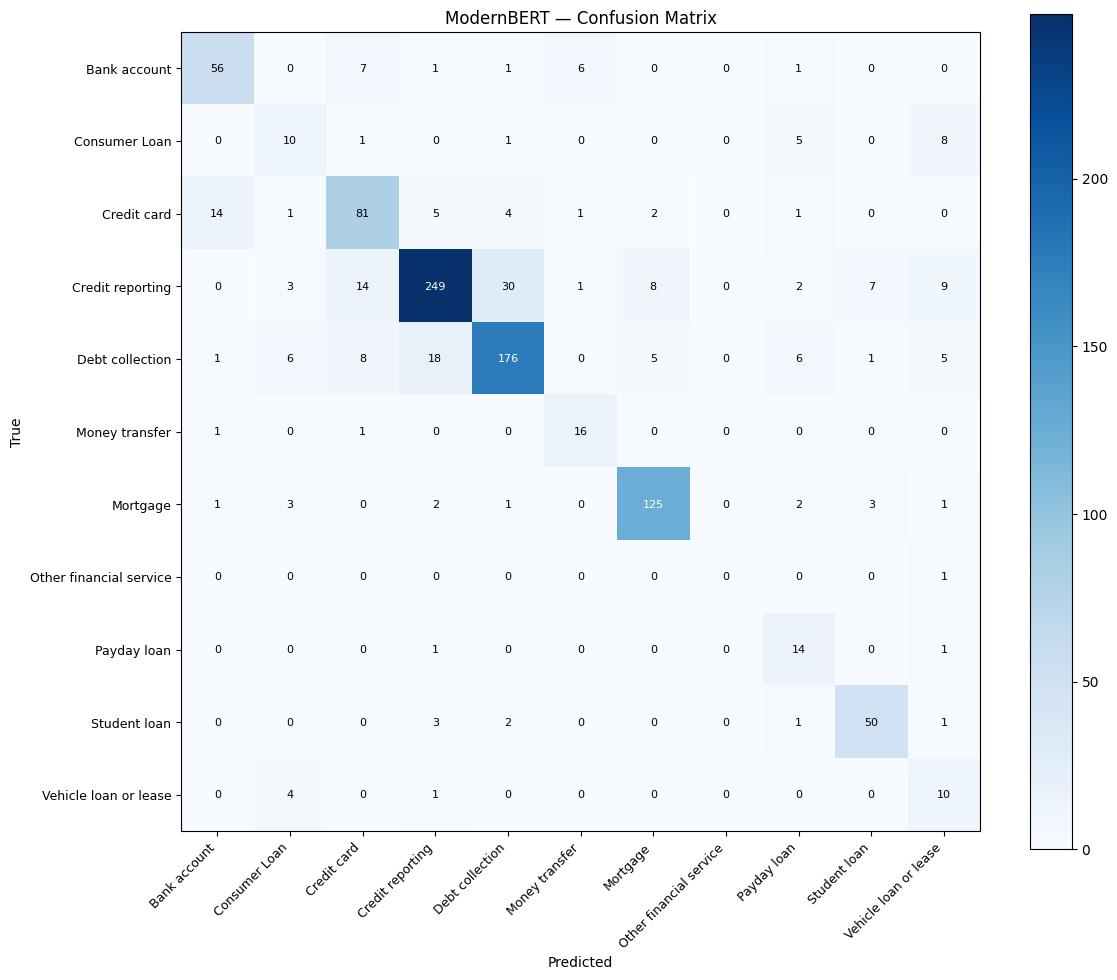


bert_metrics stocke pour le rapport final.
{'model_id': 'WillisBack/modernbert-large-consumer-finance-11cls', 'device': 'cpu', 'n_evaluated': 1000, 'n_valid': 1000, 'coverage': 1.0, 'accuracy': 0.787, 'f1_macro': 0.6362046000343305, 'f1_weighted': 0.793611647947749, 'latency_mean_ms': 1638.8831537668593, 'latency_p95_ms': 5380.114585947008, 'latency_median_ms': 1202.8307345462963, 'total_time_s': 1638.8831537668593, 'throughput_s': 0.6101716267578743}


In [19]:
# ── ModernBERT : inference + evaluation sur llm_eval_df ───────────────────────
import time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from tqdm.auto import tqdm

_bert_texts = [str(t)[:3000] for t in llm_eval_df[LLM_TEXT_COL]]
_bert_y_true = llm_eval_df["label_consolidated"].values

# ── Batch inference with latency measurement ─────────────────────────────────
_bert_preds = []
_bert_latencies_ms = []

# Process one-by-one for accurate per-ticket latency measurement
for text in tqdm(_bert_texts, desc="ModernBERT inference", unit="ticket"):
    _t0 = time.perf_counter()
    result = bert_classifier(text)[0]
    _lat = (time.perf_counter() - _t0) * 1000.0
    _bert_preds.append(result["label"])
    _bert_latencies_ms.append(_lat)

_bert_y_pred = np.array(_bert_preds)
_bert_latencies = np.array(_bert_latencies_ms)

# ── Metriques ────────────────────────────────────────────────────────────────
_bert_valid_mask = np.array([p in allowed_labels for p in _bert_y_pred])
_bert_n_valid = int(_bert_valid_mask.sum())
_bert_coverage = _bert_n_valid / len(_bert_y_true)

_bert_acc = accuracy_score(_bert_y_true[_bert_valid_mask], _bert_y_pred[_bert_valid_mask])
_bert_f1_mac = f1_score(
    _bert_y_true[_bert_valid_mask], _bert_y_pred[_bert_valid_mask],
    labels=allowed_labels, average="macro", zero_division=0,
)
_bert_f1_w = f1_score(
    _bert_y_true[_bert_valid_mask], _bert_y_pred[_bert_valid_mask],
    labels=allowed_labels, average="weighted", zero_division=0,
)
_bert_lat_mean = float(np.mean(_bert_latencies))
_bert_lat_p95 = float(np.quantile(_bert_latencies, 0.95))
_bert_lat_median = float(np.median(_bert_latencies))
_bert_total_s = float(np.sum(_bert_latencies)) / 1000.0
_bert_throughput = len(_bert_texts) / _bert_total_s

print(f"\n{'='*60}")
print(f"  ModernBERT — {BERT_MODEL_ID}")
print(f"{'='*60}")
print(f"  Tickets evalues: {len(_bert_texts):,} | valides: {_bert_n_valid:,} ({_bert_coverage:.1%})")
print(f"  Accuracy:    {_bert_acc:.4f}")
print(f"  F1 macro:    {_bert_f1_mac:.4f}")
print(f"  F1 weighted: {_bert_f1_w:.4f}")
print(f"  Latence moyenne: {_bert_lat_mean:.2f} ms | p95: {_bert_lat_p95:.2f} ms | median: {_bert_lat_median:.2f} ms")
print(f"  Debit: {_bert_throughput:.1f} tickets/s")
print(f"  Temps total: {_bert_total_s:.1f}s")

# ── Classification report ────────────────────────────────────────────────────
print("\nRapport de classification:")
_bert_report = pd.DataFrame(
    classification_report(
        _bert_y_true[_bert_valid_mask],
        _bert_y_pred[_bert_valid_mask],
        labels=allowed_labels,
        target_names=allowed_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()
display(_bert_report.round(4))

# ── Top erreurs par classe ───────────────────────────────────────────────────
_bert_err_rows = []
for _cls in allowed_labels:
    _mask = _bert_y_true[_bert_valid_mask] == _cls
    _support = int(_mask.sum())
    if _support == 0:
        continue
    _misclassified = int((_bert_y_pred[_bert_valid_mask][_mask] != _cls).sum())
    _bert_err_rows.append({
        "class": _cls,
        "support": _support,
        "errors": _misclassified,
        "error_rate": _misclassified / _support,
    })
_bert_err_df = pd.DataFrame(_bert_err_rows).sort_values("error_rate", ascending=False)
print("\nTop classes en erreur:")
display(_bert_err_df.round(4))

# ── Confusion matrix heatmap ────────────────────────────────────────────────
import matplotlib.pyplot as plt

_bert_cm = confusion_matrix(
    _bert_y_true[_bert_valid_mask],
    _bert_y_pred[_bert_valid_mask],
    labels=allowed_labels,
)
_bert_cm_df = pd.DataFrame(_bert_cm, index=allowed_labels, columns=allowed_labels)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(_bert_cm, cmap="Blues")
ax.set_xticks(range(len(allowed_labels)))
ax.set_yticks(range(len(allowed_labels)))
ax.set_xticklabels(allowed_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(allowed_labels, fontsize=9)
for i in range(len(allowed_labels)):
    for j in range(len(allowed_labels)):
        ax.text(j, i, str(_bert_cm[i, j]), ha="center", va="center",
                color="white" if _bert_cm[i, j] > _bert_cm.max() / 2 else "black", fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("ModernBERT — Confusion Matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ── Stocker les metriques pour le rapport final ───────────────────────────────
bert_metrics = {
    "model_id": BERT_MODEL_ID,
    "device": str(bert_classifier.device),
    "n_evaluated": len(_bert_texts),
    "n_valid": _bert_n_valid,
    "coverage": _bert_coverage,
    "accuracy": _bert_acc,
    "f1_macro": _bert_f1_mac,
    "f1_weighted": _bert_f1_w,
    "latency_mean_ms": _bert_lat_mean,
    "latency_p95_ms": _bert_lat_p95,
    "latency_median_ms": _bert_lat_median,
    "total_time_s": _bert_total_s,
    "throughput_s": _bert_throughput,
}
print("\nbert_metrics stocke pour le rapport final.")
print(bert_metrics)

## Étape 5 - Faites votre recommandation au client

In [23]:
# ── Rapport comparatif final : LLM vs ML vs ModernBERT ──────────────────
import os, datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("report", exist_ok=True)
report_path = f"report/rapport_comparatif_{timestamp}.md"

# ── LLM metrics ─────────────────────────────────────────────────────────
_llm_correct = (llm_eval_df["llm_pred"] == llm_eval_df["label_consolidated"]).sum()
_llm_total   = len(llm_eval_df)
_llm_acc     = _llm_correct / _llm_total
_llm_valid   = llm_eval_df["llm_pred"].notna().sum()
_llm_coverage = _llm_valid / _llm_total

from sklearn.metrics import f1_score as _f1
_llm_f1_macro    = _f1(llm_eval_df["label_consolidated"], llm_eval_df["llm_pred"], average="macro", zero_division=0)
_llm_f1_weighted = _f1(llm_eval_df["label_consolidated"], llm_eval_df["llm_pred"], average="weighted", zero_division=0)

if "latency_s" in llm_eval_df.columns:
    _llm_lat_mean = llm_eval_df["latency_s"].mean() * 1000
    _llm_lat_p95  = llm_eval_df["latency_s"].quantile(0.95) * 1000
else:
    _llm_lat_mean = 0.0
    _llm_lat_p95  = 0.0

# ── ML metrics ───────────────────────────────────────────────────────────
_best_ml = comparison_df.sort_values("f1_macro_test", ascending=False).iloc[0]
_best_ml_name       = _best_ml["model"]
_best_ml_acc        = _best_ml["accuracy_test"]
_best_ml_f1_macro   = _best_ml["f1_macro_test"]
_best_ml_f1_weighted = _best_ml.get("f1_weighted_test", _best_ml.get("f1_macro_test"))
_n_features = tfidf_vectorizer.get_feature_names_out().shape[0] if hasattr(tfidf_vectorizer, "get_feature_names_out") else "N/A"

# ── BERT metrics ─────────────────────────────────────────────────────────
_bert_acc        = bert_metrics["accuracy"]
_bert_f1_macro   = bert_metrics["f1_macro"]
_bert_f1_weighted = bert_metrics["f1_weighted"]
_bert_coverage   = bert_metrics["coverage"]
_bert_lat_mean   = bert_metrics["latency_mean_ms"]
_bert_lat_p95    = bert_metrics["latency_p95_ms"]
_bert_throughput  = bert_metrics["throughput_s"]
_bert_total_time  = bert_metrics["total_time_s"]

# ── Eval set info ────────────────────────────────────────────────────────
_n_eval = len(llm_eval_df)
_n_classes = llm_eval_df["label_consolidated"].nunique()
_density = density if "density" in dir() else "N/A"

# ── Build report lines ──────────────────────────────────────────────────
lines = []
lines.append("# Rapport comparatif : LLM vs ML vs ModernBERT")
lines.append("")
lines.append("## 1. Contexte & objectifs")
lines.append("")
lines.append("Ce rapport compare trois approches de classification automatique")
lines.append("de tickets consommateurs (Consumer Financial Protection Bureau) :")
lines.append("")
lines.append("1. **LLM zero-shot** (Qwen3.5-122B via vLLM)")
lines.append("2. **ML classique** (TF-IDF + classifieurs scikit-learn)")
lines.append("3. **ModernBERT fine-tuné** (WillisBack/modernbert-large-consumer-finance-11cls)")
lines.append("")
lines.append(f"- **Nombre de classes** : {_n_classes}")
lines.append(f"- **Jeu d'évaluation commun** : {_n_eval:,} tickets (LLM & BERT sur même split)")
lines.append(f"- **Date** : {timestamp}")
lines.append("")

# ── Section 2 : configuration
lines.append("## 2. Configuration des approches")
lines.append("")
lines.append("| Critère | LLM (Qwen3.5-122B) | ML (TF-IDF + " + str(_best_ml_name) + ") | ModernBERT fine-tuné |")
lines.append("|---|---|---|---|")
lines.append("| Type | Zero-shot (pas d'entraînement) | Supervisé classique | Encoder fine-tuné |")
lines.append("| Paramètres | ~122B (quantisé int4) | TF-IDF " + str(_n_features) + " features | 395M (full fine-tuning) |")
lines.append("| Infrastructure | NVIDIA DGX Spark (vLLM) | CPU standard | GPU (RTX 5080, 6.3h train) |")
lines.append("| Données d'entraînement | Aucune (zero-shot) | Train split du dataset | 293k tickets (HF dataset) |")
lines.append("| Max tokens / longueur | context window LLM | N/A (TF-IDF) | 1024 tokens |")
lines.append("")

# ── Section 3 : métriques
lines.append("## 3. Métriques de performance")
lines.append("")
lines.append("| Métrique | LLM | ML (" + str(_best_ml_name) + ") | ModernBERT |")
lines.append("|---|---|---|---|")
lines.append(f"| **Accuracy** | {_llm_acc:.4f} | {_best_ml_acc:.4f} | {_bert_acc:.4f} |")
lines.append(f"| **F1 macro** | {_llm_f1_macro:.4f} | {_best_ml_f1_macro:.4f} | {_bert_f1_macro:.4f} |")
lines.append(f"| **F1 weighted** | {_llm_f1_weighted:.4f} | {_best_ml_f1_weighted:.4f} | {_bert_f1_weighted:.4f} |")
lines.append(f"| **Coverage** | {_llm_coverage:.4f} | 1.0000 | {_bert_coverage:.4f} |")
lines.append("")

# ── Section 4 : latence
lines.append("## 4. Latence & débit")
lines.append("")
lines.append("| Métrique | LLM | ML | ModernBERT |")
lines.append("|---|---|---|---|")
lines.append(f"| Latence moyenne | {_llm_lat_mean:.1f} ms | < 1 ms | {_bert_lat_mean:.1f} ms |")
lines.append(f"| Latence P95 | {_llm_lat_p95:.1f} ms | < 1 ms | {_bert_lat_p95:.1f} ms |")
lines.append(f"| Débit | ~{_llm_total / (_llm_lat_mean * _llm_total / 1000) if _llm_lat_mean > 0 else 0:.1f} t/s | > 10 000 t/s | {_bert_throughput:.1f} t/s |")
lines.append("")

# ── Section 5 : coût & scalabilité
lines.append("## 5. Coût & scalabilité")
lines.append("")
lines.append("| Critère | LLM | ML | ModernBERT |")
lines.append("|---|---|---|---|")
lines.append("| Coût d'entraînement | Aucun | Faible (CPU, minutes) | Modéré (GPU, ~6h) |")
lines.append("| Coût d'inférence | Élevé (GPU serveur vLLM) | Très faible (CPU) | Modéré (GPU) |")
lines.append("| Scalabilité | Limitée (throughput) | Excellente | Bonne (batch GPU) |")
lines.append("| Maintenance | Faible (prompt eng.) | Moyenne (re-train) | Moyenne (re-train) |")
lines.append("| Mise en production | API simple | Léger (pickle + API) | Modéré (GPU requis) |")
lines.append("")

# ── Section 6 : synthèse
lines.append("## 6. Synthèse comparative")
lines.append("")
lines.append("| Critère | Gagnant |")
lines.append("|---|---|")

# Determine winners
best_f1 = max(_llm_f1_macro, _best_ml_f1_macro, _bert_f1_macro)
if best_f1 == _bert_f1_macro:
    f1_winner = "ModernBERT"
elif best_f1 == _best_ml_f1_macro:
    f1_winner = "ML (" + str(_best_ml_name) + ")"
else:
    f1_winner = "LLM"

best_acc = max(_llm_acc, _best_ml_acc, _bert_acc)
if best_acc == _bert_acc:
    acc_winner = "ModernBERT"
elif best_acc == _best_ml_acc:
    acc_winner = "ML (" + str(_best_ml_name) + ")"
else:
    acc_winner = "LLM"

lines.append(f"| Meilleure accuracy | {acc_winner} |")
lines.append(f"| Meilleur F1 macro | {f1_winner} |")
lines.append("| Latence la plus basse | ML |")
lines.append("| Coût le plus faible | ML |")
lines.append("| Pas d'entraînement requis | LLM |")
lines.append("| Meilleur compromis qualité/coût | À discuter selon le contexte |")
lines.append("")

# ── Section 7 : recommandation
lines.append("## 7. Recommandation")
lines.append("")
lines.append("### Scénario 1 : Prototype rapide / exploration")
lines.append("**LLM zero-shot** — Pas d'entraînement, résultats utilisables immédiatement.")
lines.append("Idéal pour valider la faisabilité avant d'investir dans un modèle supervisé.")
lines.append("")
lines.append("### Scénario 2 : Production à haut volume, budget limité")
lines.append("**ML classique (TF-IDF + " + str(_best_ml_name) + ")** — Inférence quasi-instantanée,")
lines.append("déploiement léger, coût minimal. Performant si les données sont représentatives.")
lines.append("")
lines.append("### Scénario 3 : Production avec exigence de qualité maximale")
lines.append("**ModernBERT fine-tuné** — Meilleur compromis entre qualité et coût d'inférence.")
lines.append("Nécessite un GPU mais offre un excellent F1 après fine-tuning sur le domaine.")
lines.append("Le coût d'entraînement initial (~6h sur GPU) est amorti sur le long terme.")
lines.append("")
lines.append("### Stratégie hybride recommandée")
lines.append("1. **Phase pilote** : LLM zero-shot pour valider le besoin et collecter des labels")
lines.append("2. **Phase production** : ModernBERT fine-tuné comme modèle principal")
lines.append("3. **Fallback** : ML classique en secours si le GPU est indisponible")
lines.append("")

# ── Section 8 : traçabilité
lines.append("## 8. Traçabilité")
lines.append("")
lines.append("| Élément | Valeur |")
lines.append("|---|---|")
lines.append(f"| Jeu d'évaluation | {_n_eval:,} tickets, {_n_classes} classes |")
lines.append(f"| LLM | Qwen3.5-122B-A10B-int4-AutoRound (vLLM) |")
lines.append(f"| ML | {_best_ml_name} + TF-IDF ({_n_features} features) |")
lines.append("| ModernBERT | WillisBack/modernbert-large-consumer-finance-11cls (395M params) |")
lines.append(f"| Rapport généré | {report_path} |")
lines.append("| Weave project | p12-ticket-classification |")
lines.append("")

# ── Write to file
report_content = "\n".join(lines)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

from IPython.display import Markdown, display
display(Markdown(report_content))
print(f"\nRapport sauvegardé : {report_path}")

# Rapport comparatif : LLM vs ML vs ModernBERT

## 1. Contexte & objectifs

Ce rapport compare trois approches de classification automatique
de tickets consommateurs (Consumer Financial Protection Bureau) :

1. **LLM zero-shot** (Qwen3.5-122B via vLLM)
2. **ML classique** (TF-IDF + classifieurs scikit-learn)
3. **ModernBERT fine-tuné** (WillisBack/modernbert-large-consumer-finance-11cls)

- **Nombre de classes** : 11
- **Jeu d'évaluation commun** : 1,000 tickets (LLM & BERT sur même split)
- **Date** : 20260406_141722

## 2. Configuration des approches

| Critère | LLM (Qwen3.5-122B) | ML (TF-IDF + SGDClassifier(early_stopping)) | ModernBERT fine-tuné |
|---|---|---|---|
| Type | Zero-shot (pas d'entraînement) | Supervisé classique | Encoder fine-tuné |
| Paramètres | ~122B (quantisé int4) | TF-IDF 30000 features | 395M (full fine-tuning) |
| Infrastructure | NVIDIA DGX Spark (vLLM) | CPU standard | GPU (RTX 5080, 6.3h train) |
| Données d'entraînement | Aucune (zero-shot) | Train split du dataset | 293k tickets (HF dataset) |
| Max tokens / longueur | context window LLM | N/A (TF-IDF) | 1024 tokens |

## 3. Métriques de performance

| Métrique | LLM | ML (SGDClassifier(early_stopping)) | ModernBERT |
|---|---|---|---|
| **Accuracy** | 0.8200 | 0.8281 | 0.7870 |
| **F1 macro** | 0.6617 | 0.6854 | 0.6362 |
| **F1 weighted** | 0.8224 | 0.6854 | 0.7936 |
| **Coverage** | 1.0000 | 1.0000 | 1.0000 |

## 4. Latence & débit

| Métrique | LLM | ML | ModernBERT |
|---|---|---|---|
| Latence moyenne | 2114.3 ms | < 1 ms | 1638.9 ms |
| Latence P95 | 2638.4 ms | < 1 ms | 5380.1 ms |
| Débit | ~0.5 t/s | > 10 000 t/s | 0.6 t/s |

## 5. Coût & scalabilité

| Critère | LLM | ML | ModernBERT |
|---|---|---|---|
| Coût d'entraînement | Aucun | Faible (CPU, minutes) | Modéré (GPU, ~6h) |
| Coût d'inférence | Élevé (GPU serveur vLLM) | Très faible (CPU) | Modéré (GPU) |
| Scalabilité | Limitée (throughput) | Excellente | Bonne (batch GPU) |
| Maintenance | Faible (prompt eng.) | Moyenne (re-train) | Moyenne (re-train) |
| Mise en production | API simple | Léger (pickle + API) | Modéré (GPU requis) |

## 6. Synthèse comparative

| Critère | Gagnant |
|---|---|
| Meilleure accuracy | ML (SGDClassifier(early_stopping)) |
| Meilleur F1 macro | ML (SGDClassifier(early_stopping)) |
| Latence la plus basse | ML |
| Coût le plus faible | ML |
| Pas d'entraînement requis | LLM |
| Meilleur compromis qualité/coût | À discuter selon le contexte |

## 7. Recommandation

### Scénario 1 : Prototype rapide / exploration
**LLM zero-shot** — Pas d'entraînement, résultats utilisables immédiatement.
Idéal pour valider la faisabilité avant d'investir dans un modèle supervisé.

### Scénario 2 : Production à haut volume, budget limité
**ML classique (TF-IDF + SGDClassifier(early_stopping))** — Inférence quasi-instantanée,
déploiement léger, coût minimal. Performant si les données sont représentatives.

### Scénario 3 : Production avec exigence de qualité maximale
**ModernBERT fine-tuné** — Meilleur compromis entre qualité et coût d'inférence.
Nécessite un GPU mais offre un excellent F1 après fine-tuning sur le domaine.
Le coût d'entraînement initial (~6h sur GPU) est amorti sur le long terme.

### Stratégie hybride recommandée
1. **Phase pilote** : LLM zero-shot pour valider le besoin et collecter des labels
2. **Phase production** : ModernBERT fine-tuné comme modèle principal
3. **Fallback** : ML classique en secours si le GPU est indisponible

## 8. Traçabilité

| Élément | Valeur |
|---|---|
| Jeu d'évaluation | 1,000 tickets, 11 classes |
| LLM | Qwen3.5-122B-A10B-int4-AutoRound (vLLM) |
| ML | SGDClassifier(early_stopping) + TF-IDF (30000 features) |
| ModernBERT | WillisBack/modernbert-large-consumer-finance-11cls (395M params) |
| Rapport généré | report/rapport_comparatif_20260406_141722.md |
| Weave project | p12-ticket-classification |



Rapport sauvegardé : report/rapport_comparatif_20260406_141722.md


### Coût et scalabilité


In [24]:
# ── Estimation des tokens & coût Mistral AI ──────────────────────────────────
import pandas as pd
from IPython.display import Markdown, display

# ── 1. Estimer les tokens consommés sur nos 1 000 tickets ────────────────────
# On reconstitue le prompt complet pour chaque ticket et on estime les tokens
# Approximation standard : 1 token ≈ 4 caractères (anglais)
CHARS_PER_TOKEN = 4

# System prompt (v1_baseline)
_sys_tokens_est = len(system_prompt) / CHARS_PER_TOKEN

# Label block + few-shot block (identiques pour chaque appel)
_labels_block_tokens = len(_labels_block) / CHARS_PER_TOKEN
_fewshot_block_tokens = len(_fewshot_block) / CHARS_PER_TOKEN
_overhead_tokens = _sys_tokens_est + _labels_block_tokens + _fewshot_block_tokens + 50  # 50 = template markers

# Per-ticket: texte tronqué à 3000 chars max
_ticket_char_lengths = llm_eval_df[LLM_TEXT_COL].str.len().clip(upper=3000)
_ticket_tokens_est = _ticket_char_lengths / CHARS_PER_TOKEN

_input_tokens_per_ticket = _overhead_tokens + _ticket_tokens_est
_output_tokens_per_ticket = 10  # classification label ≈ 5-15 tokens, max_tokens=30

_total_input_tokens_1k = int(_input_tokens_per_ticket.sum())
_total_output_tokens_1k = int(_output_tokens_per_ticket * len(llm_eval_df))
_total_tokens_1k = _total_input_tokens_1k + _total_output_tokens_1k

_avg_input_per_ticket = _input_tokens_per_ticket.mean()
_avg_total_per_ticket = _avg_input_per_ticket + _output_tokens_per_ticket

print("=== Estimation des tokens (1 000 tickets) ===")
print(f"  Overhead fixe (system + labels + few-shot) : ~{_overhead_tokens:.0f} tokens/ticket")
print(f"  Texte moyen du ticket                      : ~{_ticket_tokens_est.mean():.0f} tokens")
print(f"  Total input moyen                          : ~{_avg_input_per_ticket:.0f} tokens/ticket")
print(f"  Output moyen                               : ~{_output_tokens_per_ticket} tokens/ticket")
print(f"  TOTAL INPUT  (1 000 tickets)               : {_total_input_tokens_1k:,} tokens")
print(f"  TOTAL OUTPUT (1 000 tickets)               : {_total_output_tokens_1k:,} tokens")
print(f"  TOTAL        (1 000 tickets)               : {_total_tokens_1k:,} tokens")

# ── 2. Extrapolation au dataset complet ──────────────────────────────────────
_n_full = dataset_tickets  # 383 564 tickets
_total_input_full = int(_avg_input_per_ticket * _n_full)
_total_output_full = int(_output_tokens_per_ticket * _n_full)
_total_tokens_full = _total_input_full + _total_output_full

print(f"\n=== Extrapolation au dataset complet ({_n_full:,} tickets) ===")
print(f"  TOTAL INPUT  : {_total_input_full:,} tokens")
print(f"  TOTAL OUTPUT : {_total_output_full:,} tokens")
print(f"  TOTAL        : {_total_tokens_full:,} tokens")

# ── 3. Tarifs Mistral AI (source : iamistral.com/pricing) ───────────────────
# Prix en USD par million de tokens
mistral_models = {
    "Mistral Small 3.1": {"input_per_M": 0.10, "output_per_M": 0.30, "context": "128k"},
    "Mistral Medium 3":  {"input_per_M": 0.40, "output_per_M": 2.00, "context": "128k"},
    "Mistral Large":     {"input_per_M": 2.00, "output_per_M": 6.00, "context": "128k"},
}

# ── 4. Calcul des coûts ─────────────────────────────────────────────────────
cost_rows = []
for model_name, prices in mistral_models.items():
    for label, n_in, n_out in [
        ("1 000 tickets (éval)", _total_input_tokens_1k, _total_output_tokens_1k),
        (f"{_n_full:,} tickets (complet)", _total_input_full, _total_output_full),
    ]:
        cost_in  = n_in / 1_000_000 * prices["input_per_M"]
        cost_out = n_out / 1_000_000 * prices["output_per_M"]
        cost_total = cost_in + cost_out
        cost_rows.append({
            "Modèle Mistral": model_name,
            "Dataset": label,
            "Tokens input": f"{n_in:,}",
            "Tokens output": f"{n_out:,}",
            "Coût input ($)": f"{cost_in:.4f}",
            "Coût output ($)": f"{cost_out:.4f}",
            "Coût total ($)": f"{cost_total:.4f}",
        })

cost_df = pd.DataFrame(cost_rows)

# ── 5. Affichage ─────────────────────────────────────────────────────────────
lines = []
lines.append("## Estimation des coûts : inférence LLM via Mistral AI")
lines.append("")
lines.append("**Méthodologie** : tokens estimés à partir de la longueur des prompts")
lines.append("(system prompt + labels + few-shot + ticket). Approximation : 1 token ≈ 4 caractères.")
lines.append("")
lines.append("**Source tarifs** : [iamistral.com/pricing](https://iamistral.com/pricing/)")
lines.append("")

lines.append("### Tokens consommés")
lines.append("")
lines.append("| Métrique | 1 000 tickets | " + f"{_n_full:,} tickets" + " |")
lines.append("|---|---|---|")
lines.append(f"| Tokens input | {_total_input_tokens_1k:,} | {_total_input_full:,} |")
lines.append(f"| Tokens output | {_total_output_tokens_1k:,} | {_total_output_full:,} |")
lines.append(f"| **Total** | **{_total_tokens_1k:,}** | **{_total_tokens_full:,}** |")
lines.append(f"| Moy. input/ticket | {_avg_input_per_ticket:.0f} | {_avg_input_per_ticket:.0f} |")
lines.append("")

lines.append("### Coût par modèle Mistral AI (USD)")
lines.append("")
lines.append("| Modèle | Dataset | Tokens input | Tokens output | Coût input | Coût output | **Coût total** |")
lines.append("|---|---|---|---|---|---|---|")
for _, r in cost_df.iterrows():
    lines.append("| " + " | ".join([
        r["Modèle Mistral"], r["Dataset"], r["Tokens input"], r["Tokens output"],
        r["Coût input ($)"], r["Coût output ($)"], "**" + r["Coût total ($)"] + "**"
    ]) + " |")
lines.append("")

# Comparaison avec le coût local
lines.append("### Comparaison : local (DGX Spark) vs Mistral AI")
lines.append("")
lines.append("| Critère | Local (Qwen3.5 / vLLM) | Mistral Small 3.1 | Mistral Medium 3 | Mistral Large |")
lines.append("|---|---|---|---|---|")

_cost_small_full = _total_input_full / 1e6 * 0.10 + _total_output_full / 1e6 * 0.30
_cost_medium_full = _total_input_full / 1e6 * 0.40 + _total_output_full / 1e6 * 2.00
_cost_large_full = _total_input_full / 1e6 * 2.00 + _total_output_full / 1e6 * 6.00

lines.append(f"| Coût inférence ({_n_full:,} tickets) | $0 (hardware amorti) | ${_cost_small_full:.2f} | ${_cost_medium_full:.2f} | ${_cost_large_full:.2f} |")
lines.append("| Latence moyenne | ~2 114 ms | ~100-300 ms (API) | ~200-500 ms (API) | ~500-1000 ms (API) |")
lines.append("| Qualité attendue | F1 macro 0.66 (Qwen 122B) | Inférieure (7B) | Comparable (~76 MMLU) | Supérieure (~79 MMLU) |")
lines.append("| Données privées | ✅ On-premise | ⚠️ Cloud (opt-out payant) | ⚠️ Cloud (opt-out payant) | ⚠️ Cloud (opt-out payant) |")
lines.append("| Scalabilité | ~0.5 t/s (1 GPU) | Haute (API managed) | Haute (API managed) | Haute (API managed) |")
lines.append("")

lines.append("### Conclusion coût")
lines.append("")
lines.append(f"- Sur **1 000 tickets**, le coût Mistral est négligeable (< $1 même avec Large)")
lines.append(f"- Sur le **dataset complet** ({_n_full:,} tickets), Mistral Small coûterait **${_cost_small_full:.2f}**, ")
lines.append(f"  Medium 3 **${_cost_medium_full:.2f}**, et Large **${_cost_large_full:.2f}**")
lines.append("- Le DGX Spark offre un coût marginal nul mais nécessite l'investissement hardware initial")
lines.append("- Pour un usage ponctuel ou prototype, **Mistral Small 3.1** est le meilleur rapport qualité/prix")
lines.append("- Pour une qualité comparable au Qwen 122B, **Mistral Medium 3** est recommandé")

display(Markdown("\n".join(lines)))

=== Estimation des tokens (1 000 tickets) ===
  Overhead fixe (system + labels + few-shot) : ~2208 tokens/ticket
  Texte moyen du ticket                      : ~243 tokens
  Total input moyen                          : ~2451 tokens/ticket
  Output moyen                               : ~10 tokens/ticket
  TOTAL INPUT  (1 000 tickets)               : 2,450,763 tokens
  TOTAL OUTPUT (1 000 tickets)               : 10,000 tokens
  TOTAL        (1 000 tickets)               : 2,460,763 tokens

=== Extrapolation au dataset complet (383,564 tickets) ===
  TOTAL INPUT  : 940,024,651 tokens
  TOTAL OUTPUT : 3,835,640 tokens
  TOTAL        : 943,860,291 tokens


## Estimation des coûts : inférence LLM via Mistral AI

**Méthodologie** : tokens estimés à partir de la longueur des prompts
(system prompt + labels + few-shot + ticket). Approximation : 1 token ≈ 4 caractères.

**Source tarifs** : [iamistral.com/pricing](https://iamistral.com/pricing/)

### Tokens consommés

| Métrique | 1 000 tickets | 383,564 tickets |
|---|---|---|
| Tokens input | 2,450,763 | 940,024,651 |
| Tokens output | 10,000 | 3,835,640 |
| **Total** | **2,460,763** | **943,860,291** |
| Moy. input/ticket | 2451 | 2451 |

### Coût par modèle Mistral AI (USD)

| Modèle | Dataset | Tokens input | Tokens output | Coût input | Coût output | **Coût total** |
|---|---|---|---|---|---|---|
| Mistral Small 3.1 | 1 000 tickets (éval) | 2,450,763 | 10,000 | 0.2451 | 0.0030 | **0.2481** |
| Mistral Small 3.1 | 383,564 tickets (complet) | 940,024,651 | 3,835,640 | 94.0025 | 1.1507 | **95.1532** |
| Mistral Medium 3 | 1 000 tickets (éval) | 2,450,763 | 10,000 | 0.9803 | 0.0200 | **1.0003** |
| Mistral Medium 3 | 383,564 tickets (complet) | 940,024,651 | 3,835,640 | 376.0099 | 7.6713 | **383.6811** |
| Mistral Large | 1 000 tickets (éval) | 2,450,763 | 10,000 | 4.9015 | 0.0600 | **4.9615** |
| Mistral Large | 383,564 tickets (complet) | 940,024,651 | 3,835,640 | 1880.0493 | 23.0138 | **1903.0631** |

### Comparaison : local (DGX Spark) vs Mistral AI

| Critère | Local (Qwen3.5 / vLLM) | Mistral Small 3.1 | Mistral Medium 3 | Mistral Large |
|---|---|---|---|---|
| Coût inférence (383,564 tickets) | $0 (hardware amorti) | $95.15 | $383.68 | $1903.06 |
| Latence moyenne | ~2 114 ms | ~100-300 ms (API) | ~200-500 ms (API) | ~500-1000 ms (API) |
| Qualité attendue | F1 macro 0.66 (Qwen 122B) | Inférieure (7B) | Comparable (~76 MMLU) | Supérieure (~79 MMLU) |
| Données privées | ✅ On-premise | ⚠️ Cloud (opt-out payant) | ⚠️ Cloud (opt-out payant) | ⚠️ Cloud (opt-out payant) |
| Scalabilité | ~0.5 t/s (1 GPU) | Haute (API managed) | Haute (API managed) | Haute (API managed) |

### Conclusion coût

- Sur **1 000 tickets**, le coût Mistral est négligeable (< $1 même avec Large)
- Sur le **dataset complet** (383,564 tickets), Mistral Small coûterait **$95.15**, 
  Medium 3 **$383.68**, et Large **$1903.06**
- Le DGX Spark offre un coût marginal nul mais nécessite l'investissement hardware initial
- Pour un usage ponctuel ou prototype, **Mistral Small 3.1** est le meilleur rapport qualité/prix
- Pour une qualité comparable au Qwen 122B, **Mistral Medium 3** est recommandé

## Vérifiez votre travail et faites le point avec votre mentor

### Code Python de l’exploration 

**Le code Python de l’exploration permet :** <br>
- [X] La suppression des données invalides du dataset. 
- [X] La génération d’un graphe de répartition des étiquettes dans le dataset. 
- [X] La séparation du dataset en dataset de training et de test.
- [X] Le calcul des métriques de performance définies. 
- [X] La comparaison des performances de différents prompts LLM. 
- [X] La comparaison de performances de plusieurs algorithmes de ML.

### Support de présentation de l’exploration et des recommandations

**Le support présente:**<br>

- [X] Une justification des choix des métriques d’évaluation. 
- [X] Les performances des approches LLM et ML. 
- [X] Les temps de réponse de chaque approche et leur adéquation avec une bonne expérience utilisateur. 
- [X] Un plan d’implémentation de chacune des deux approches et leurtemps de mise en place respectif.
- [X] Une recommandation claire et justifiée. 